# Import Libraries

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, BatchNormalization,
    Dropout, Dense
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
warnings.filterwarnings('ignore')

# import the necessary libraries

2026-04-18 22:58:48.381076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776553128.563926      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776553128.623175      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776553129.092047      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776553129.092086      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776553129.092088      55 computation_placer.cc:177] computation placer alr

NameError: name 'warnings' is not defined

# Exploring the dataset

## Cell 1 — Inspect the directory structure first


In [3]:
import os

for split in ['train', 'test']:
    path = f'/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/{split}'
    print(f"\n{split}/")
    for cls in os.listdir(path):
        count = len(os.listdir(os.path.join(path, cls)))
        print(f"  {cls}: {count} images")


train/
  benign: 5000 images
  malignant: 4605 images

test/
  benign: 500 images
  malignant: 500 images


In [4]:
train_dir = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'
test_dir = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'

# define dataset paths

## Create validation split from train (since dataset has no val folder)

In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split

train_dir = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'
test_dir  = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'

# Kaggle input is read-only, so we write the new structure to /kaggle/working
WORK_DIR = '/kaggle/working/data'

def create_val_split(train_dir, output_dir, val_ratio=0.15):
    """
    Kaggle dataset only has train/test.
    Paper uses 70/15/15 — we carve 15% out of train as val.
    Copies files (doesn't move) since /kaggle/input is read-only.
    """
    classes = [d for d in os.listdir(train_dir)
               if os.path.isdir(os.path.join(train_dir, d))]
    print(f"Classes found: {classes}")

    for split in ['train', 'val']:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(train_dir, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Split train into 85% train / 15% val
        # (test set already provided separately by the dataset)
        train_imgs, val_imgs = train_test_split(
            images, test_size=val_ratio, random_state=42
        )

        for split_name, split_imgs in [('train', train_imgs),
                                        ('val',   val_imgs)]:
            for img in split_imgs:
                src = os.path.join(cls_path, img)
                dst = os.path.join(output_dir, split_name, cls, img)
                shutil.copy2(src, dst)

        print(f"  {cls}: {len(train_imgs)} train | {len(val_imgs)} val")

create_val_split(train_dir, WORK_DIR)

# Copy test folder as-is (read-only safe via symlink alternative)
classes = [d for d in os.listdir(test_dir)
           if os.path.isdir(os.path.join(test_dir, d))]
for cls in classes:
    os.makedirs(os.path.join(WORK_DIR, 'test', cls), exist_ok=True)
    for img in os.listdir(os.path.join(test_dir, cls)):
        shutil.copy2(
            os.path.join(test_dir, cls, img),
            os.path.join(WORK_DIR, 'test', cls, img)
        )
print("\nTest set copied.")

Classes found: ['benign', 'malignant']
  benign: 4250 train | 750 val
  malignant: 3914 train | 691 val

Test set copied.


### Verify final counts

In [5]:
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_path = os.path.join(WORK_DIR, split)
    for cls in sorted(os.listdir(split_path)):
        count = len(os.listdir(os.path.join(split_path, cls)))
        print(f"  {cls}: {count} images")


train/
  benign: 4250 images
  malignant: 3914 images

val/
  benign: 750 images
  malignant: 691 images

test/
  benign: 500 images
  malignant: 500 images


# Data Preprocessing & Data Augmentation

**Custom Preprocessing Functions**

In [7]:
def remove_artifacts(image):
    """Remove dark borders, color calibration marks, frame shadows."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    image = cv2.bitwise_and(image, image, mask=mask)
    return image

def enhance_contrast(image):
    """CLAHE contrast enhancement per channel."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels = cv2.split(image)
    enhanced = [clahe.apply(ch) for ch in channels]
    return cv2.merge(enhanced)

def remove_hair(image):
    """Detect hair-like linear patterns and inpaint them."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    # Inpaint removes detected hair regions
    result = cv2.inpaint(image, hair_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    return result

def apply_median_filter(image):
    """Median filter to reduce noise while preserving lesion boundaries."""
    return cv2.medianBlur(image, 3)

def full_preprocessing_pipeline(image):
    """
    Apply all Table 3 steps in order:
    1. Artifact removal
    2. Contrast enhancement
    3. Hair removal
    4. Median filtering
    5. Pixel normalization to [0, 1]
    (Resizing to 224x224 is handled by flow_from_directory's target_size)
    """
    image = image.astype(np.uint8)
    image = remove_artifacts(image)
    image = enhance_contrast(image)
    image = remove_hair(image)
    image = apply_median_filter(image)
    image = image.astype(np.float32) / 255.0  # normalize to [0, 1]
    return image

**Training generator — augmentation**

In [8]:
# Applied ONLY to training set, NOT to val or test
train_datagen = ImageDataGenerator(
    preprocessing_function=full_preprocessing_pipeline,

    # Geometric augmentation (Table 4)
    horizontal_flip=True,
    rotation_range=20,          # paper: "within ±20°"
    zoom_range=0.2,             # paper: "up to 20%"

    # Brightness adjustment (Table 4)
    brightness_range=[0.8, 1.2],

    # Shuffling is handled per epoch by shuffle=True in flow_from_directory
)




In [9]:
# ─── Validation & test generator — NO augmentation ──────────────────────────
# Paper: "validation and test sets remained unchanged"

val_test_datagen = ImageDataGenerator(
    preprocessing_function=full_preprocessing_pipeline
)


In [10]:
# ─── Data generators ─────────────────────────────────────────────────────────
# Paper: batch size = 16, image size = 224x224, 2 classes (benign / malignant)

BATCH_SIZE = 16
IMG_SIZE   = (224, 224)

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True              # Table 4: shuffled before each epoch
)

val_generator = val_test_datagen.flow_from_directory(
    'data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    'data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8164 images belonging to 2 classes.
Found 1441 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


# Build the Model

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, BatchNormalization, Dropout,
    Dense, Input
)
from tensorflow.keras.regularizers import l2

def build_proposed_model(input_shape=(224, 224, 3), num_classes=2):
    """
    Proposed model from the paper (Fig. 4):
    Pretrained Xception → GlobalAveragePooling → Custom dense stack
    with BatchNorm, Dropout, ReLU+L2, and Swish activations → Softmax
    """

    # ── Base: pretrained Xception (frozen) ──────────────────────────────────
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # freeze base during initial training

    # ── Custom head (Fig. 4, top to bottom) ─────────────────────────────────
    x = base_model.output

    # Block 1 — GAP + BN
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    # Block 2 — Dense 256 ReLU + L2
    x = Dropout(0.1)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)

    # Block 3 — Dense 128 ReLU + L2
    x = Dropout(0.1)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)

    # Block 4 — Dense 32 ReLU + L2
    x = Dropout(0.1)(x)
    x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)

    # Block 5 — Dense 64 Swish
    x = Dropout(0.1)(x)
    x = Dense(64, activation='swish')(x)
    x = BatchNormalization()(x)

    # Block 6 — Dense 1024 Swish
    x = Dropout(0.3)(x)
    x = Dense(1024, activation='swish')(x)
    x = BatchNormalization()(x)

    # Block 7 — Dense 512 Swish
    x = Dropout(0.3)(x)
    x = Dense(512, activation='swish')(x)
    x = BatchNormalization()(x)

    # Block 8 — Dense 128 Swish
    x = Dropout(0.3)(x)
    x = Dense(128, activation='swish')(x)

    # Output — Softmax (Eq. 8)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

model = build_proposed_model()
model.summary()

I0000 00:00:1776553352.517291      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776553352.523671      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 22,098,698 (84.30 MB)

 Trainable params: 1,229,090 (4.69 MB)

 Non-trainable params: 20,869,608 (79.61 MB)

## Compile with paper's exact training specifications

In [14]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # paper: lr = 1×10⁻⁴
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

## Callbacks (early stopping + best model checkpoint)

In [15]:
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

callbacks = [
    # Paper: early stopping with patience = 3
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model by val_accuracy
    ModelCheckpoint(
        filepath='/kaggle/working/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Optional but helpful: reduce lr if val_loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

## Train (Phase 1: frozen base)

In [16]:
print("=" * 50)
print("Phase 1: Training with frozen Xception base")
print("=" * 50)

history_phase1 = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=callbacks
)

Phase 1: Training with frozen Xception base


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1776553400.960986     155 service.cc:152] XLA service 0x7bb14c00d300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776553400.961043     155 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776553400.961049     155 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776553402.868835     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-18 23:03:30.573182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:03:30.727017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:03:31.925436: E external/local_xl

 68/511 ━━━━━━━━━━━━━━━━━━━━ 5:09 698ms/step - accuracy: 0.5765 - auc: 0.5890 - loss: 7.6444 - precision: 0.5765 - recall: 0.5765

2026-04-18 23:04:35.560155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:04:35.705183: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:04:35.841779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:04:36.632368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:04:36.766027: E external/local_xla/xla/stream_

511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.6297 - auc: 0.6726 - loss: 7.4632 - precision: 0.6297 - recall: 0.6297

2026-04-18 23:11:07.083051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:11:07.220830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:11:07.353793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:11:08.185691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 23:11:08.317800: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.83761, saving model to /kaggle/working/best_model.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 483s 888ms/step - accuracy: 0.6298 - auc: 0.6728 - loss: 7.4628 - precision: 0.6298 - recall: 0.6298 - val_accuracy: 0.8376 - val_auc: 0.9039 - val_loss: 6.8047 - val_precision: 0.8376 - val_recall: 0.8376 - learning_rate: 1.0000e-04
Epoch 2/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.7588 - auc: 0.8356 - loss: 6.8333 - precision: 0.7588 - recall: 0.7588
Epoch 2: val_accuracy improved from 0.83761 to 0.85982, saving model to /kaggle/working/best_model.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 418s 819ms/step - accuracy: 0.7589 - auc: 0.8356 - loss: 6.8331 - precision: 0.7589 - recall: 0.7589 - val_accuracy: 0.8598 - val_auc: 0.9307 - val_loss: 6.2956 - val_precision: 0.8598 - val_recall: 0.8598 - learning_rate: 1.0000e-04
Epoch 3/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.8018 - auc: 0.8753 - loss: 6.2869 - precision: 0.8018 - r

## Fine-tune (Phase 2: unfreeze top Xception layers)

In [19]:
# Print all layer names and types to find the Xception base
for i, layer in enumerate(model.layers):
    print(f"{i:3d}  {layer.name:40s}  {type(layer).__name__}")

  0  input_layer                               InputLayer
  1  block1_conv1                              Conv2D
  2  block1_conv1_bn                           BatchNormalization
  3  block1_conv1_act                          Activation
  4  block1_conv2                              Conv2D
  5  block1_conv2_bn                           BatchNormalization
  6  block1_conv2_act                          Activation
  7  block2_sepconv1                           SeparableConv2D
  8  block2_sepconv1_bn                        BatchNormalization
  9  block2_sepconv2_act                       Activation
 10  block2_sepconv2                           SeparableConv2D
 11  block2_sepconv2_bn                        BatchNormalization
 12  conv2d                                    Conv2D
 13  block2_pool                               MaxPooling2D
 14  batch_normalization                       BatchNormalization
 15  add                                       Add
 16  block3_sepconv1_act               

In [21]:
# ── Phase 2: fine-tune top 30 Xception layers ────────────────────────────────

# All Xception base layers start with 'block' or 'input_layer' or 'conv2d'
# Our custom head starts from 'global_average_pooling2d' onward
# So we identify the base layers by excluding our custom head layers

custom_head_names = {
    'global_average_pooling2d', 'global_average_pooling2d_1',
    'batch_normalization_4', 'batch_normalization_5',
    'batch_normalization_6', 'batch_normalization_7',
    'batch_normalization_8', 'batch_normalization_9', 'batch_normalization_10',
    'dropout',   'dropout_1', 'dropout_2', 'dropout_3',
    'dropout_4', 'dropout_5', 'dropout_6',
    'dense',     'dense_1',   'dense_2',   'dense_3',
    'dense_4',   'dense_5',   'dense_6',   'dense_7'
}

# Separate base layers from custom head
base_layers = [l for l in model.layers if l.name not in custom_head_names]

print(f"Total layers          : {len(model.layers)}")
print(f"Base (Xception) layers: {len(base_layers)}")

# Freeze all base layers first
for layer in base_layers:
    layer.trainable = False

# Then unfreeze the last 30 base layers
for layer in base_layers[-30:]:
    layer.trainable = True

# Confirm
frozen    = sum(1 for l in model.layers if not l.trainable)
trainable = sum(1 for l in model.layers if l.trainable)
print(f"Frozen layers         : {frozen}")
print(f"Trainable layers      : {trainable}")

# Recompile with lower lr
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\n" + "=" * 50)
print("Phase 2: Fine-tuning top 30 Xception layers")
print("=" * 50)

history_phase2 = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

print("\nDone. Best model saved to /kaggle/working/best_model.keras")

Total layers          : 155
Base (Xception) layers: 132
Frozen layers         : 102
Trainable layers      : 53

Phase 2: Fine-tuning top 30 Xception layers
Epoch 1/50


2026-04-19 00:06:21.923320: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 00:06:22.058668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 76/511 ━━━━━━━━━━━━━━━━━━━━ 5:17 730ms/step - accuracy: 0.7632 - auc: 0.8480 - loss: 4.8835 - precision: 0.7632 - recall: 0.7632

2026-04-19 00:07:30.204274: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 00:07:30.340942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 00:07:30.474557: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.7800 - auc: 0.8599 - loss: 4.8430 - precision: 0.7800 - recall: 0.7800
Epoch 1: val_accuracy did not improve from 0.87162
511/511 ━━━━━━━━━━━━━━━━━━━━ 473s 875ms/step - accuracy: 0.7800 - auc: 0.8599 - loss: 4.8429 - precision: 0.7800 - recall: 0.7800 - val_accuracy: 0.8647 - val_auc: 0.9367 - val_loss: 4.6439 - val_precision: 0.8647 - val_recall: 0.8647 - learning_rate: 1.0000e-05
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.8211 - auc: 0.9003 - loss: 4.7082 - precision: 0.8211 - recall: 0.8211
Epoch 2: val_accuracy did not improve from 0.87162
511/511 ━━━━━━━━━━━━━━━━━━━━ 451s 882ms/step - accuracy: 0.8211 - auc: 0.9003 - loss: 4.7082 - precision: 0.8211 - recall: 0.8211 - val_accuracy: 0.8688 - val_auc: 0.9434 - val_loss: 4.5745 - val_precision: 0.8688 - val_recall: 0.8688 - learning_rate: 1.0000e-05
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.8393 - auc: 0.9172 - loss: 4.6163 - p

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step

2026-04-19 01:08:09.113927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 01:08:09.255582: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 01:08:10.399909: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 01:08:10.533468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 01:08:11.365235: E external/local_xla/xla/stream_

63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 825ms/step

Classification Report
              precision    recall  f1-score   support

      benign       0.89      0.94      0.91       500
   malignant       0.94      0.88      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

Test Accuracy : 0.9090
Test AUC      : 0.9549
Test F1       : 0.9089


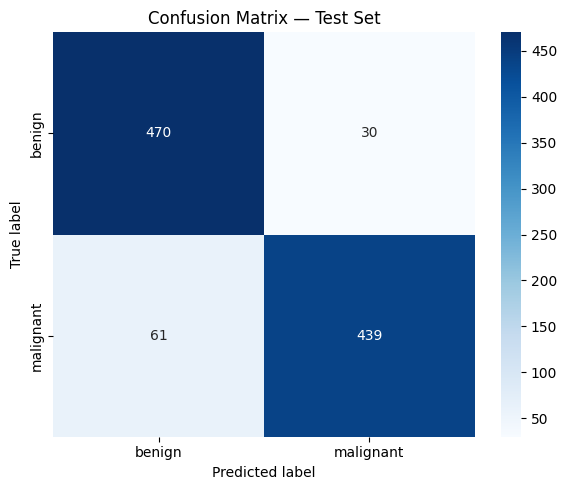

Saved: confusion_matrix.png


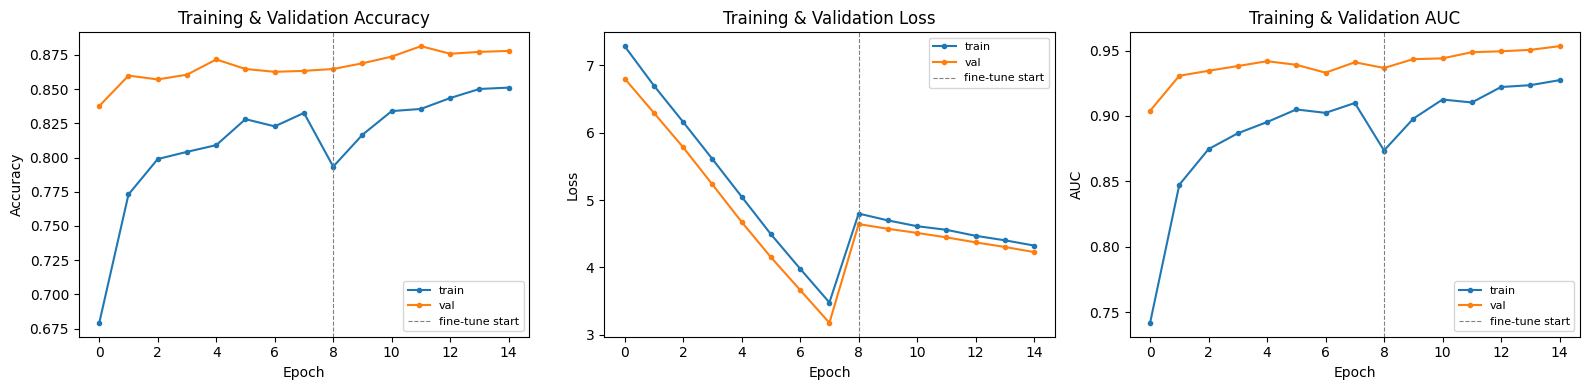

Saved: training_curves.png


IndexError: index 0 is out of bounds for axis 0 with size 0

In [23]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score
)

# ── Load best model ───────────────────────────────────────────────────────────
model = tf.keras.models.load_model('/kaggle/working/best_model.keras')
print("Model loaded successfully")

# ── Test set predictions ──────────────────────────────────────────────────────
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes
class_names  = list(test_generator.class_indices.keys())

# ── Classification report (Eq. 9–11) ─────────────────────────────────────────
print("\n" + "=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

auc = roc_auc_score(y_true, y_pred_probs[:, 1])
f1  = f1_score(y_true, y_pred, average='weighted')
acc = np.mean(y_true == y_pred)
print(f"Test Accuracy : {acc:.4f}")
print(f"Test AUC      : {auc:.4f}")
print(f"Test F1       : {f1:.4f}")

# ── Confusion matrix (Fig. 5) ─────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# ── Training curves (Fig. 6–8) ────────────────────────────────────────────────
def merge_histories(h1, h2, metric):
    return h1.history[metric] + h2.history[metric]

metrics   = ['accuracy', 'loss', 'auc']
titles    = ['Accuracy', 'Loss', 'AUC']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, title in zip(axes, metrics, titles):
    ax.plot(merge_histories(history_phase1, history_phase2, metric),
            label='train', marker='o', markersize=3)
    ax.plot(merge_histories(history_phase1, history_phase2, f'val_{metric}'),
            label='val',   marker='o', markersize=3)
    # Mark the phase boundary
    boundary = len(history_phase1.history[metric])
    ax.axvline(x=boundary, color='gray', linestyle='--',
               linewidth=0.8, label='fine-tune start')
    ax.set_title(f'Training & Validation {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print("Saved: training_curves.png")

# ── Grad-CAM (Eq. 12, Fig. 13) ───────────────────────────────────────────────
def get_gradcam_heatmap(model, image_array, last_conv_layer_name):
    """Compute Grad-CAM heatmap for a single image."""
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            np.expand_dims(image_array, axis=0)
        )
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]

    grads       = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_class.numpy()

def get_saliency_map(model, image_array):
    """Compute Saliency Map (Eq. 13) for a single image."""
    image_tensor = tf.cast(
        np.expand_dims(image_array, axis=0), tf.float32
    )
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        predictions  = model(image_tensor)
        pred_class   = tf.argmax(predictions[0])
        class_score  = predictions[:, pred_class]

    grads       = tape.gradient(class_score, image_tensor)
    saliency    = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    saliency    = saliency / (tf.math.reduce_max(saliency) + 1e-8)
    return saliency.numpy(), pred_class.numpy()

def overlay_heatmap(image, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on the original image."""
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    image_uint8     = np.uint8(255 * image)
    overlaid        = cv2.addWeighted(image_uint8, 1 - alpha,
                                      heatmap_colored, alpha, 0)
    return overlaid

# Last conv layer in Xception
LAST_CONV_LAYER = 'block14_sepconv2_act'

# ── Pick one benign and one malignant sample from test set ────────────────────
test_generator.reset()
images_batch, labels_batch = next(iter(test_generator))

# Find first benign (class 0) and first malignant (class 1)
benign_idx    = np.where(np.argmax(labels_batch, axis=1) == 0)[0][0]
malignant_idx = np.where(np.argmax(labels_batch, axis=1) == 1)[0][0]

samples = {
    'Benign'   : images_batch[benign_idx],
    'Malignant': images_batch[malignant_idx]
}

# ── Plot XAI results (Fig. 13–14 style) ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
row_labels = list(samples.keys())

for row_idx, (label, image) in enumerate(samples.items()):

    heatmap, pred_class = get_gradcam_heatmap(
        model, image, LAST_CONV_LAYER
    )
    saliency, _         = get_saliency_map(model, image)
    overlaid            = overlay_heatmap(image, heatmap)
    pred_name           = class_names[pred_class]

    # Original
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(
        f'Original\nTrue: {label}  |  Pred: {pred_name}', fontsize=10
    )
    axes[row_idx, 0].axis('off')

    # Grad-CAM
    axes[row_idx, 1].imshow(overlaid)
    axes[row_idx, 1].set_title(f'Grad-CAM: {label}', fontsize=10)
    axes[row_idx, 1].axis('off')

    # Saliency Map
    axes[row_idx, 2].imshow(saliency, cmap='hot')
    axes[row_idx, 2].set_title(f'Saliency Map: {label}', fontsize=10)
    axes[row_idx, 2].axis('off')

plt.suptitle('Explainable AI — Grad-CAM & Saliency Maps', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/xai_results.png', dpi=150)
plt.show()
print("Saved: xai_results.png")

print("\n" + "=" * 50)
print("All outputs saved to /kaggle/working/")
print("  - best_model.keras")
print("  - confusion_matrix.png")
print("  - training_curves.png")
print("  - xai_results.png")
print("=" * 50)

Benign sample found    : True
Malignant sample found : True


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


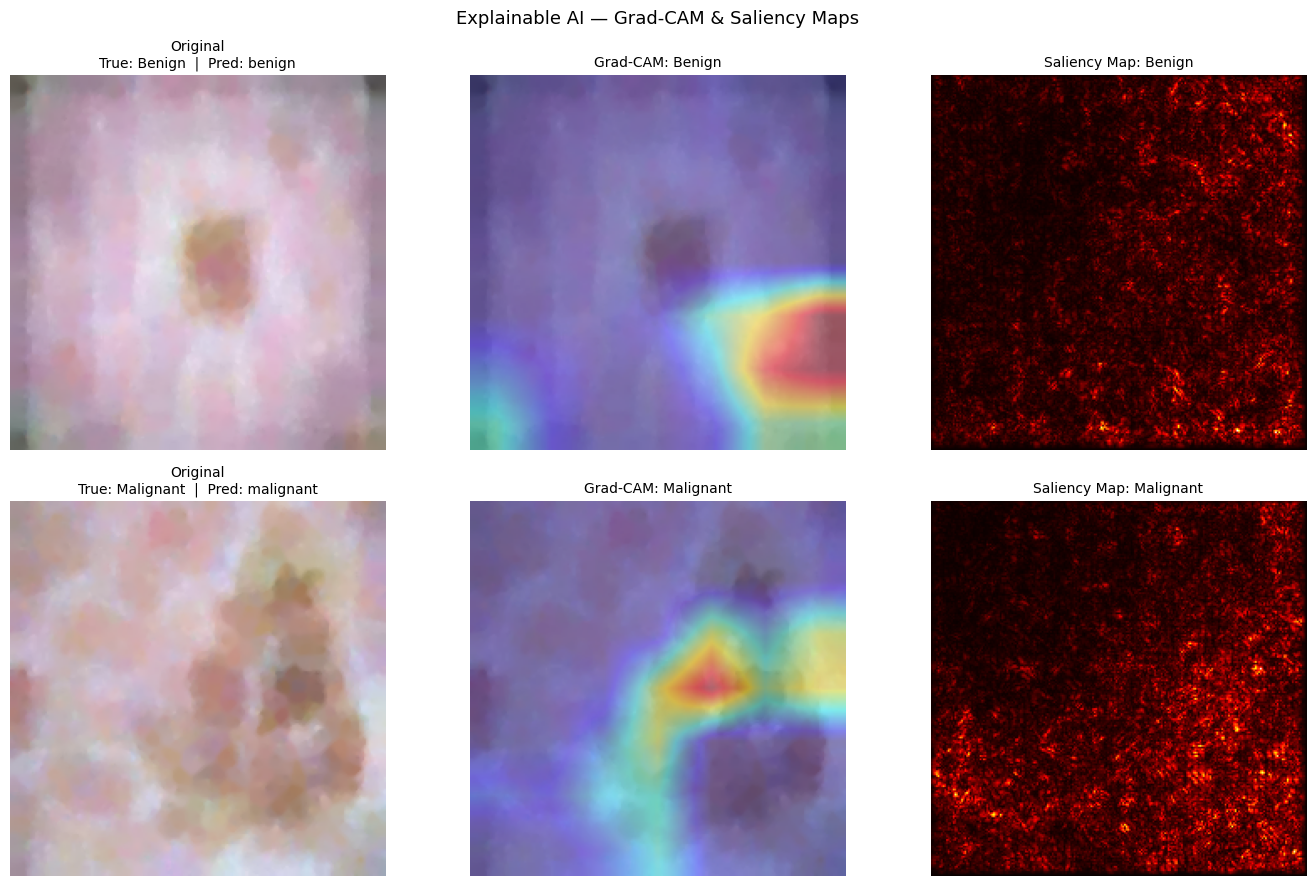

Saved: xai_results.png


In [24]:
# ── Find one benign and one malignant sample across batches ──────────────────
test_generator.reset()

benign_image    = None
malignant_image = None

for images_batch, labels_batch in test_generator:
    labels = np.argmax(labels_batch, axis=1)

    if benign_image is None:
        idxs = np.where(labels == 0)[0]
        if len(idxs) > 0:
            benign_image = images_batch[idxs[0]]

    if malignant_image is None:
        idxs = np.where(labels == 1)[0]
        if len(idxs) > 0:
            malignant_image = images_batch[idxs[0]]

    # Stop as soon as we have both
    if benign_image is not None and malignant_image is not None:
        break

print(f"Benign sample found    : {benign_image is not None}")
print(f"Malignant sample found : {malignant_image is not None}")

samples = {
    'Benign'   : benign_image,
    'Malignant': malignant_image
}

# ── Plot XAI results ──────────────────────────────────────────────────────────
LAST_CONV_LAYER = 'block14_sepconv2_act'

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for row_idx, (label, image) in enumerate(samples.items()):

    heatmap, pred_class = get_gradcam_heatmap(model, image, LAST_CONV_LAYER)
    saliency, _         = get_saliency_map(model, image)
    overlaid            = overlay_heatmap(image, heatmap)
    pred_name           = class_names[pred_class]

    # Original
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(
        f'Original\nTrue: {label}  |  Pred: {pred_name}', fontsize=10
    )
    axes[row_idx, 0].axis('off')

    # Grad-CAM
    axes[row_idx, 1].imshow(overlaid)
    axes[row_idx, 1].set_title(f'Grad-CAM: {label}', fontsize=10)
    axes[row_idx, 1].axis('off')

    # Saliency Map
    axes[row_idx, 2].imshow(saliency, cmap='hot')
    axes[row_idx, 2].set_title(f'Saliency Map: {label}', fontsize=10)
    axes[row_idx, 2].axis('off')

plt.suptitle('Explainable AI — Grad-CAM & Saliency Maps', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/xai_results.png', dpi=150)
plt.show()
print("Saved: xai_results.png")

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models                  # keep for reference only
import timm                                     # Xception comes from here
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Check timm has Xception ───────────────────────────────────────────────────
print(f"timm version : {timm.__version__}")
xception_models = [m for m in timm.list_models() if 'xception' in m.lower()]
print(f"Xception variants available in timm : {xception_models}")

# ── Paths & constants ─────────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/melanoma-cancer-dataset'
WORK_DIR     = '/kaggle/working/dataset1'
BATCH_SIZE   = 16
IMG_SIZE     = 224
NUM_CLASSES  = 2
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("Imports OK")

Device : cuda
GPU    : Tesla T4
timm version : 1.0.25
Xception variants available in timm : ['legacy_xception', 'xception41', 'xception41p', 'xception65', 'xception65p', 'xception71']
Imports OK


In [4]:
import os

# Check what's available in /kaggle/input
print("Available datasets in /kaggle/input:")
for d in os.listdir('/kaggle/input'):
    print(f"  /kaggle/input/{d}")

Available datasets in /kaggle/input:
  /kaggle/input/datasets


In [6]:
# After running the check above, set the correct path
# It will be something like one of these:

# Option A — if you added bhaveshmittal's dataset
DATASET_PATH = '/kaggle/input/melanoma-cancer-dataset'

# Option B — if you're using hasnainjaved (already attached)
DATASET_PATH = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images'

# Verify it exists and show structure
if os.path.exists(DATASET_PATH):
    print(f"\n✓ Found dataset at: {DATASET_PATH}")
    print("\nStructure:")
    for root, dirs, files in os.walk(DATASET_PATH):
        level = root.replace(DATASET_PATH, '').count(os.sep)
        if level < 4:
            indent = '  ' * level
            imgs = [f for f in files
                    if f.lower().endswith(('.jpg','.jpeg','.png'))]
            print(f"{indent}{os.path.basename(root)}/  "
                  f"{'→ ' + str(len(imgs)) + ' images' if imgs else ''}")
else:
    print(f"✗ Not found: {DATASET_PATH}")
    print("  → Add the dataset via the Kaggle UI first")


✓ Found dataset at: /kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images

Structure:
melanoma-skin-cancer-dataset-of-10000-images/  
  melanoma_cancer_dataset/  
    test/  
      benign/  → 500 images
      malignant/  → 500 images
    train/  
      benign/  → 5000 images
      malignant/  → 4605 images


In [8]:
def organize_dataset(source_dir, output_dir):
    """Split 70/15/15 as per the paper."""

    # Auto-find where the actual images live
    actual_source = None
    for root, dirs, files in os.walk(source_dir):
        images = [f for f in files
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(images) > 10:
            actual_source = os.path.dirname(root)
            break

    if actual_source is None:
        actual_source = source_dir

    classes = [d for d in os.listdir(actual_source)
               if os.path.isdir(os.path.join(actual_source, d))]
    print(f"Classes found: {classes}")
    print(f"Source      : {actual_source}")

    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(actual_source, cls)
        images   = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        train_imgs, temp_imgs = train_test_split(
            images, test_size=0.30, random_state=RANDOM_SEED
        )
        val_imgs, test_imgs = train_test_split(
            temp_imgs, test_size=0.50, random_state=RANDOM_SEED
        )

        for split_name, split_imgs in [('train', train_imgs),
                                        ('val',   val_imgs),
                                        ('test',  test_imgs)]:
            for img in split_imgs:
                shutil.copy2(
                    os.path.join(cls_path, img),
                    os.path.join(output_dir, split_name, cls, img)
                )
        print(f"  {cls}: {len(train_imgs)} train | "
              f"{len(val_imgs)} val | {len(test_imgs)} test")

if not os.path.exists(WORK_DIR):
    print("Organizing dataset...")
    organize_dataset(DATASET_PATH, WORK_DIR)
else:
    print(f"Split already exists at {WORK_DIR}")

# Verify
print("\nFinal counts:")
for split in ['train', 'val', 'test']:
    for cls in sorted(os.listdir(os.path.join(WORK_DIR, split))):
        count = len(os.listdir(os.path.join(WORK_DIR, split, cls)))
        print(f"  {split}/{cls}: {count}")

Split already exists at /kaggle/working/dataset1

Final counts:
  train/benign: 350
  train/malignant: 350
  val/benign: 75
  val/malignant: 75
  test/benign: 75
  test/malignant: 75


In [9]:
# ── Preprocessing functions (Table 3) ────────────────────────────────────────
def remove_artifacts(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return cv2.bitwise_and(image, image, mask=mask)

def enhance_contrast(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels = cv2.split(image)
    enhanced = [clahe.apply(ch) for ch in channels]
    return cv2.merge(enhanced)

def remove_hair(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image, hair_mask, inpaintRadius=3,
                       flags=cv2.INPAINT_TELEA)

def apply_median_filter(image):
    return cv2.medianBlur(image, 3)

def preprocess_image(image_array):
    """Full Table 3 pipeline. Input: uint8 RGB numpy array."""
    image_array = remove_artifacts(image_array)
    image_array = enhance_contrast(image_array)
    image_array = remove_hair(image_array)
    image_array = apply_median_filter(image_array)
    return image_array  # still uint8, normalization done by transforms


# ── Custom Dataset ────────────────────────────────────────────────────────────
class MelanomaDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_train=False):
        self.root_dir  = root_dir
        self.transform = transform
        self.is_train  = is_train
        self.classes   = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((
                        os.path.join(cls_path, img_name),
                        self.class_to_idx[cls]
                    ))

        print(f"Loaded {len(self.samples)} images | "
              f"Classes: {self.class_to_idx}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Load as RGB numpy array
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply Table 3 preprocessing
        image = preprocess_image(image)

        # Convert to PIL for torchvision transforms
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label


# ── Transforms (Table 4) ──────────────────────────────────────────────────────
# Training: augmentation + normalize to [0,1]
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                      # Table 4
    transforms.RandomRotation(20),                          # Table 4: ±20°
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1)), # Table 4: zoom 20%
    transforms.ColorJitter(brightness=0.2),                 # Table 4: brightness
    transforms.ToTensor(),                                  # → [0,1] float32
])

# Val/Test: no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_dataset = MelanomaDataset(
    os.path.join(WORK_DIR, 'train'),
    transform=train_transform,
    is_train=True
)
val_dataset = MelanomaDataset(
    os.path.join(WORK_DIR, 'val'),
    transform=val_test_transform
)
test_dataset = MelanomaDataset(
    os.path.join(WORK_DIR, 'test'),
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset,   batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Loaded 700 images | Classes: {'benign': 0, 'malignant': 1}
Loaded 150 images | Classes: {'benign': 0, 'malignant': 1}
Loaded 150 images | Classes: {'benign': 0, 'malignant': 1}

Train batches : 44
Val batches   : 10
Test batches  : 10


In [10]:
class ProposedModel(nn.Module):
    """
    Xception (pretrained) + custom head from Fig. 4.
    Uses timm for Xception since torchvision doesn't include it.
    """
    def __init__(self, num_classes=2, freeze_base=True):
        super(ProposedModel, self).__init__()

        # ── Pretrained Xception base (timm) ───────────────────────────────────
        self.base = timm.create_model(
            'xception',
            pretrained=True,
            num_classes=0,      # remove classifier head
            global_pool=''      # remove global pooling (we add our own)
        )

        if freeze_base:
            for param in self.base.parameters():
                param.requires_grad = False

        base_out_features = 2048  # Xception final conv output channels

        # ── Custom head (Fig. 4, top → bottom) ───────────────────────────────
        self.gap = nn.AdaptiveAvgPool2d(1)   # GlobalAveragePooling2D

        self.head = nn.Sequential(
            # Block 1: BN after GAP
            nn.BatchNorm1d(base_out_features),

            # Block 2: Dense 256 ReLU + L2 (weight_decay handles L2)
            nn.Dropout(0.1),
            nn.Linear(base_out_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            # Block 3: Dense 128 ReLU + L2
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            # Block 4: Dense 32 ReLU + L2
            nn.Dropout(0.1),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            # Block 5: Dense 64 Swish
            nn.Dropout(0.1),
            nn.Linear(32, 64),
            nn.SiLU(),           # SiLU == Swish in PyTorch
            nn.BatchNorm1d(64),

            # Block 6: Dense 1024 Swish
            nn.Dropout(0.3),
            nn.Linear(64, 1024),
            nn.SiLU(),
            nn.BatchNorm1d(1024),

            # Block 7: Dense 512 Swish
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),

            # Block 8: Dense 128 Swish
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.SiLU(),

            # Output: Softmax (Eq. 8)
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.base(x)           # (B, 2048, H, W)
        x = self.gap(x)            # (B, 2048, 1, 1)
        x = x.flatten(1)           # (B, 2048)
        x = self.head(x)           # (B, num_classes)
        return x                   # raw logits (CrossEntropyLoss handles softmax)

    def unfreeze_top_layers(self, n_layers=30):
        """Unfreeze last n layers of Xception base for fine-tuning."""
        all_layers = list(self.base.children())
        for layer in all_layers:
            for param in layer.parameters():
                param.requires_grad = False

        # Unfreeze last n_layers
        layers_to_unfreeze = all_layers[-n_layers:]
        for layer in layers_to_unfreeze:
            for param in layer.parameters():
                param.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters()
                        if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"Trainable params: {trainable:,} / {total:,}")


model = ProposedModel(num_classes=NUM_CLASSES, freeze_base=True).to(device)
print("Model built successfully")

# Quick sanity check
dummy = torch.randn(2, 3, 224, 224).to(device)
out   = model(dummy)
print(f"Output shape: {out.shape}")  # should be (2, 2)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Model built successfully
Output shape: torch.Size([2, 2])


In [12]:
def run_training(model, train_loader, val_loader,
                 n_epochs, lr, phase_name,
                 patience=10, save_path='/kaggle/working/best_model.pth'):

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-3
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=3, min_lr=1e-7              # removed verbose=True
    )

    best_val_acc = 0.0
    patience_ctr = 0
    history      = {'train_loss': [], 'train_acc': [],
                    'val_loss':   [], 'val_acc':   [], 'val_auc': []}

    print(f"\n{'='*55}")
    print(f"{phase_name}")
    print(f"{'='*55}")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, val_auc = val_epoch(
            model, val_loader, criterion
        )

        # Print lr so we can see when it drops (replaces verbose=True)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        print(f"Epoch {epoch:03d}/{n_epochs} | "
              f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} "
              f"auc: {val_auc:.4f} | lr: {current_lr:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model (val_acc: {best_val_acc:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val_acc: {best_val_acc:.4f}")
    return history


# ── Phase 1: frozen base ──────────────────────────────────────────────────────
history_p1 = run_training(
    model, train_loader, val_loader,
    n_epochs=100,
    lr=1e-4,
    phase_name='Phase 1 — Frozen Xception base',
    patience=10,
    save_path='/kaggle/working/best_model.pth'
)

# ── Phase 2: fine-tune top layers ─────────────────────────────────────────────
model.unfreeze_top_layers(n_layers=30)

history_p2 = run_training(
    model, train_loader, val_loader,
    n_epochs=50,
    lr=1e-5,
    phase_name='Phase 2 — Fine-tuning top 30 Xception layers',
    patience=5,
    save_path='/kaggle/working/best_model.pth'
)


Phase 1 — Frozen Xception base


Epoch 001/100 | Train loss: 0.6187 acc: 0.6271 | Val loss: 0.5190 acc: 0.8067 auc: 0.8905 | lr: 1.00e-04
  ✓ Saved best model (val_acc: 0.8067)


Epoch 002/100 | Train loss: 0.4543 acc: 0.7971 | Val loss: 0.3744 acc: 0.8467 auc: 0.9191 | lr: 1.00e-04
  ✓ Saved best model (val_acc: 0.8467)


Epoch 003/100 | Train loss: 0.4080 acc: 0.8271 | Val loss: 0.3483 acc: 0.8400 auc: 0.9317 | lr: 1.00e-04


Epoch 004/100 | Train loss: 0.4026 acc: 0.8029 | Val loss: 0.3462 acc: 0.8467 auc: 0.9269 | lr: 1.00e-04


...

Epoch 009/50 | Train loss: 0.2956 acc: 0.8729 | Val loss: 0.3110 acc: 0.9067 auc: 0.9339 | lr: 1.00e-05


Epoch 010/50 | Train loss: 0.3147 acc: 0.8729 | Val loss: 0.2948 acc: 0.8867 auc: 0.9381 | lr: 1.00e-05


Epoch 011/50 | Train loss: 0.2710 acc: 0.8914 | Val loss: 0.2928 acc: 0.8933 auc: 0.9428 | lr: 1.00e-05


Epoch 012/50 | Train loss: 0.2673 acc: 0.9029 | Val loss: 0.3097 acc: 0.9067 auc: 0.9355 | lr: 1.00e-05


Epoch 013/50 | Train loss: 0.2924 acc: 0.8800 | Val loss: 0.2894 acc: 0.9000 auc: 0.9403 | lr: 1.00e-05
  Early stopping at epoch 13

Best val_acc: 0.9067


In [13]:
# تحميل أحسن weight اتحفظ
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
print("✓ Loaded best model weights")

def run_training_continued(model, train_loader, val_loader,
                           n_epochs, lr, phase_name,
                           patience=15,
                           save_path='/kaggle/working/best_model.pth'):

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-3
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs,   # cosine annealing أحسن من ReduceLROnPlateau
        eta_min=1e-7
    )

    best_val_acc = 0.0
    patience_ctr = 0
    history      = {'train_loss': [], 'train_acc': [],
                    'val_loss':   [], 'val_acc':   [], 'val_auc': []}

    print(f"\n{'='*55}")
    print(f"{phase_name}")
    print(f"{'='*55}")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, val_auc = val_epoch(
            model, val_loader, criterion
        )

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        print(f"Epoch {epoch:03d}/{n_epochs} | "
              f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} "
              f"auc: {val_auc:.4f} | lr: {current_lr:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model (val_acc: {best_val_acc:.4f})")
        else:
            patience_ctr += 1
            print(f"  patience: {patience_ctr}/{patience}")
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val_acc: {best_val_acc:.4f}")
    return history


# ── Phase 3: فتح كل طبقات الـ Xception ───────────────────────────────────────
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

history_p3 = run_training_continued(
    model, train_loader, val_loader,
    n_epochs=50,
    lr=5e-6,          
    phase_name='Phase 3 — Full model fine-tuning',
    patience=15,      
    save_path='/kaggle/working/best_model.pth'
)

✓ Loaded best model weights
Trainable params: 22,036,042 / 22,036,042

Phase 3 — Full model fine-tuning


Epoch 001/50 | Train loss: 0.2726 acc: 0.8843 | Val loss: 0.3128 acc: 0.9067 auc: 0.9360 | lr: 5.00e-06
  ✓ Saved best model (val_acc: 0.9067)


Epoch 002/50 | Train loss: 0.2868 acc: 0.8814 | Val loss: 0.3181 acc: 0.9067 auc: 0.9397 | lr: 5.00e-06
  patience: 1/15


Epoch 003/50 | Train loss: 0.2815 acc: 0.8871 | Val loss: 0.2961 acc: 0.9067 auc: 0.9399 | lr: 4.98e-06
  patience: 2/15


Epoch 004/50 | Train loss: 0.2697 acc: 0.8929 | Val loss: 0.2957 acc: 0.9067 auc: 0.9383 | lr: 4.96e-06
  patience: 3/15


...

Epoch 024/50 | Train loss: 0.3003 acc: 0.8843 | Val loss: 0.2915 acc: 0.9000 auc: 0.9415 | lr: 2.86e-06
  patience: 11/15


Epoch 025/50 | Train loss: 0.2323 acc: 0.9114 | Val loss: 0.2875 acc: 0.8933 auc: 0.9420 | lr: 2.70e-06
  patience: 12/15


Epoch 026/50 | Train loss: 0.2393 acc: 0.9014 | Val loss: 0.2928 acc: 0.8867 auc: 0.9408 | lr: 2.55e-06
  patience: 13/15


Epoch 027/50 | Train loss: 0.2535 acc: 0.9071 | Val loss: 0.2862 acc: 0.8933 auc: 0.9419 | lr: 2.40e-06
  patience: 14/15


Epoch 028/50 | Train loss: 0.2613 acc: 0.8914 | Val loss: 0.2948 acc: 0.8933 auc: 0.9397 | lr: 2.24e-06
  patience: 15/15
  Early stopping at epoch 28

Best val_acc: 0.9200


#-__-________________________________________________________________________


In [2]:
!pip install optuna timm -q

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
import optuna
import optuna.visualization.matplotlib as optuna_vis
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from tqdm import tqdm

# ── Device & GPU info ─────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f"Device     : {device}")
print(f"GPUs found : {n_gpus}")
for i in range(n_gpus):
    print(f"  GPU {i}  : {torch.cuda.get_device_name(i)}")

# ── Constants ─────────────────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images'
WORK_DIR     = '/kaggle/working/dataset1'
IMG_SIZE     = 224
NUM_CLASSES  = 2
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("\nAll imports OK ✓")

Device     : cuda
GPUs found : 2
  GPU 0  : Tesla T4
  GPU 1  : Tesla T4

All imports OK ✓


In [3]:
 # Organize Dataset (70/15/15)
def organize_dataset(source_dir, output_dir):
    """
    Auto-finds class folders and splits 70/15/15
    as per the paper. Skips if already done.
    """
    if os.path.exists(output_dir):
        print(f"✓ Dataset already organized at {output_dir}")
        return

    # Auto-find where images actually are
    actual_source = source_dir
    for root, dirs, files in os.walk(source_dir):
        imgs = [f for f in files
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(imgs) > 10:
            actual_source = os.path.dirname(root)
            break

    classes = [d for d in os.listdir(actual_source)
                if os.path.isdir(os.path.join(actual_source, d))]
    print(f"Classes found : {classes}")
    print(f"Source        : {actual_source}")

    # Create split folders
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(
                os.path.join(output_dir, split, cls),
                exist_ok=True
            )

    for cls in classes:
        cls_path = os.path.join(actual_source, cls)
        images   = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))]

        train_imgs, temp   = train_test_split(
            images, test_size=0.30, random_state=RANDOM_SEED
        )
        val_imgs, test_imgs = train_test_split(
            temp, test_size=0.50, random_state=RANDOM_SEED
        )

        for split_name, split_imgs in [('train', train_imgs),
                                        ('val',   val_imgs),
                                        ('test',  test_imgs)]:
            for img in split_imgs:
                shutil.copy2(
                    os.path.join(cls_path, img),
                    os.path.join(output_dir, split_name, cls, img)
                )

        print(f"  {cls}: {len(train_imgs)} train | "
              f"{len(val_imgs)} val | {len(test_imgs)} test")

organize_dataset(DATASET_PATH, WORK_DIR)

# Verify
print("\nFinal split counts:")
for split in ['train', 'val', 'test']:
    print(f"\n  {split}/")
    for cls in sorted(os.listdir(os.path.join(WORK_DIR, split))):
        n = len(os.listdir(os.path.join(WORK_DIR, split, cls)))
        print(f"    {cls}: {n} images")

Classes found : ['benign', 'malignant']
Source        : /kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test
  benign: 350 train | 75 val | 75 test
  malignant: 350 train | 75 val | 75 test

Final split counts:

  train/
    benign: 350 images
    malignant: 350 images

  val/
    benign: 75 images
    malignant: 75 images

  test/
    benign: 75 images
    malignant: 75 images


In [4]:
# ── Table 3 preprocessing functions ──────────────────────────────────────────
def remove_artifacts(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask    = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    return cv2.bitwise_and(image, image, mask=mask)

def enhance_contrast(image):
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels = cv2.split(image)
    return cv2.merge([clahe.apply(ch) for ch in channels])

def remove_hair(image):
    gray     = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask  = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

def apply_median_filter(image):
    return cv2.medianBlur(image, 3)

def preprocess_image(image):
    image = remove_artifacts(image)
    image = enhance_contrast(image)
    image = remove_hair(image)
    image = apply_median_filter(image)
    return image


# ── Dataset class ─────────────────────────────────────────────────────────────
class MelanomaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform    = transform
        self.classes      = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = []

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_path):
                if img_name.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((
                        os.path.join(cls_path, img_name),
                        self.class_to_idx[cls]
                    ))

        # Weights for balanced sampling
        class_counts  = [0] * NUM_CLASSES
        for _, lbl in self.samples:
            class_counts[lbl] += 1
        self.weights = [1.0 / class_counts[lbl]
                        for _, lbl in self.samples]

        print(f"  {root_dir.split('/')[-1]:6s} → "
              f"{len(self.samples)} images | "
              f"classes: {self.class_to_idx}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = preprocess_image(image)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Transforms (Table 4) ──────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ── Load datasets ─────────────────────────────────────────────────────────────
print("Loading datasets...")
train_dataset = MelanomaDataset(
    os.path.join(WORK_DIR, 'train'), transform=train_transform
)
val_dataset   = MelanomaDataset(
    os.path.join(WORK_DIR, 'val'),   transform=val_test_transform
)
test_dataset  = MelanomaDataset(
    os.path.join(WORK_DIR, 'test'),  transform=val_test_transform
)
print("✓ Datasets loaded")

Loading datasets...
  train  → 700 images | classes: {'benign': 0, 'malignant': 1}
  val    → 150 images | classes: {'benign': 0, 'malignant': 1}
  test   → 150 images | classes: {'benign': 0, 'malignant': 1}
✓ Datasets loaded


In [5]:
# Model Definition
class ProposedModel(nn.Module):
    """Fig. 4 architecture with tunable dropout & dense sizes."""
    def __init__(self, dropout_1=0.1, dropout_2=0.3,
                 dense_1=256, dense_2=1024, freeze_base=True):
        super().__init__()

        self.base = timm.create_model(
            'xception', pretrained=True,
            num_classes=0, global_pool=''
        )
        if freeze_base:
            for p in self.base.parameters():
                p.requires_grad = False

        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.BatchNorm1d(2048),

            nn.Dropout(dropout_1),
            nn.Linear(2048,   dense_1), nn.ReLU(),
            nn.BatchNorm1d(dense_1),

            nn.Dropout(dropout_1),
            nn.Linear(dense_1, 128),    nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Dropout(dropout_1),
            nn.Linear(128,     32),     nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Dropout(dropout_1),
            nn.Linear(32,      64),     nn.SiLU(),
            nn.BatchNorm1d(64),

            nn.Dropout(dropout_2),
            nn.Linear(64,    dense_2),  nn.SiLU(),
            nn.BatchNorm1d(dense_2),

            nn.Dropout(dropout_2),
            nn.Linear(dense_2, 512),    nn.SiLU(),
            nn.BatchNorm1d(512),

            nn.Dropout(dropout_2),
            nn.Linear(512,     128),    nn.SiLU(),

            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        x = self.base(x)
        x = self.gap(x).flatten(1)
        return self.head(x)

    def unfreeze_all(self):
        for p in self.parameters():
            p.requires_grad = True
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"✓ All layers unfrozen — trainable params: {n:,}")

In [6]:
# Training Utilities
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(device)
    return (lam * x + (1 - lam) * x[index],
            y, y[index], lam)

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_epoch(model, loader, optimizer, criterion, use_mixup=False):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            images, la, lb, lam = mixup_data(images, labels)
            outputs = model(images)
            loss    = mixup_criterion(criterion, outputs, la, lb, lam)
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels      = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val  ', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)

            total_loss += criterion(outputs, labels).item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc        = roc_auc_score(all_labels, all_probs[:, 1])
    return total_loss / total, correct / total, auc


def run_training(model, train_loader, val_loader, criterion,
                 n_epochs, lr, phase_name,
                 patience=15, use_mixup=False,
                 save_path='/kaggle/working/best_model.pth'):

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-3
    )

    def lr_lambda(epoch):
        warmup = 5
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(n_epochs - warmup, 1)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler    = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    best_val_acc = 0.0
    patience_ctr = 0
    history      = {k: [] for k in ['train_loss', 'train_acc',
                                     'val_loss',   'val_acc', 'val_auc']}

    print(f"\n{'='*55}\n{phase_name}\n{'='*55}")

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc         = train_epoch(
            model, train_loader, optimizer, criterion, use_mixup
        )
        vl_loss, vl_acc, vl_auc = val_epoch(model, val_loader, criterion)
        current_lr              = optimizer.param_groups[0]['lr']
        scheduler.step()

        for k, v in zip(
            ['train_loss','train_acc','val_loss','val_acc','val_auc'],
            [tr_loss, tr_acc, vl_loss, vl_acc, vl_auc]
        ):
            history[k].append(v)

        print(f"Epoch {epoch:03d}/{n_epochs} | "
              f"Train loss:{tr_loss:.4f} acc:{tr_acc:.4f} | "
              f"Val loss:{vl_loss:.4f} acc:{vl_acc:.4f} "
              f"auc:{vl_auc:.4f} | lr:{current_lr:.2e}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved (val_acc: {best_val_acc:.4f})")
        else:
            patience_ctr += 1
            print(f"  patience: {patience_ctr}/{patience}")
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val_acc: {best_val_acc:.4f}")
    return history

In [7]:
 # Optuna Search
def objective(trial):
    # Hyperparameters to search
    lr           = trial.suggest_float('lr', 1e-6, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [16, 32, 64])
    label_smooth = trial.suggest_float('label_smoothing', 0.0, 0.2, step=0.05)
    dropout_1    = trial.suggest_float('dropout_1', 0.0, 0.3, step=0.05)
    dropout_2    = trial.suggest_float('dropout_2', 0.1, 0.5, step=0.05)
    dense_1      = trial.suggest_categorical('dense_1', [128, 256, 512])
    dense_2      = trial.suggest_categorical('dense_2', [512, 1024, 2048])

    print(f"\nTrial {trial.number} | lr={lr:.2e} bs={batch_size} "
          f"ls={label_smooth:.2f} d1={dropout_1:.2f} d2={dropout_2:.2f} "
          f"dense1={dense_1} dense2={dense_2}")

    # DataLoaders
    sampler = WeightedRandomSampler(
        weights=train_dataset.weights,
        num_samples=len(train_dataset),
        replacement=True
    )
    t_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        sampler=sampler, num_workers=2, pin_memory=True
    )
    v_loader = DataLoader(
        val_dataset, batch_size=batch_size,
        shuffle=False, num_workers=2, pin_memory=True
    )

    # Build model
    model = ProposedModel(
        dropout_1=dropout_1, dropout_2=dropout_2,
        dense_1=dense_1,     dense_2=dense_2,
        freeze_base=False    # unfreeze last 30 for trials
    ).to(device)

    # Unfreeze only last 30 base layers for speed
    all_params = list(model.base.parameters())
    for p in all_params[:-30]:
        p.requires_grad = False

    if n_gpus > 1:
        model = nn.DataParallel(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=15, eta_min=1e-7
    )

    best_auc = 0.0
    for epoch in range(15):
        # Train
        model.train()
        for images, labels in t_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            optimizer.step()
        scheduler.step()

        # Validate
        model.eval()
        all_probs, all_labels = [], []
        correct, total        = 0, 0
        with torch.no_grad():
            for images, labels in v_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                probs   = torch.softmax(outputs, dim=1)
                correct += (outputs.argmax(1) == labels).sum().item()
                total   += images.size(0)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        val_auc = roc_auc_score(
            np.concatenate(all_labels),
            np.concatenate(all_probs)[:, 1]
        )
        val_acc = correct / total

        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        best_auc = max(best_auc, val_auc)
        print(f"  Epoch {epoch+1:02d}/15 | "
              f"acc:{val_acc:.4f} auc:{val_auc:.4f}")

    del model
    torch.cuda.empty_cache()
    return best_auc


# Run Optuna
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5, n_warmup_steps=5
    ),
    study_name='melanoma_tuning'
)

study.optimize(objective, n_trials=20, timeout=7200,
               show_progress_bar=True)

print(f"\nBest AUC    : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

[I 2026-04-29 23:01:49,954] A new study created in memory with name: melanoma_tuning


  0%|          | 0/20 [00:00<?, ?it/s]


Trial 0 | lr=1.33e-05 bs=16 ls=0.00 d1=0.00 d2=0.45 dense1=256 dense2=512


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
  Epoch 01/15 | acc:0.4933 auc:0.6244
  Epoch 02/15 | acc:0.6200 auc:0.6743
  Epoch 03/15 | acc:0.5600 auc:0.6910
  Epoch 04/15 | acc:0.6067 auc:0.7420
  Epoch 05/15 | acc:0.6733 auc:0.7561
  Epoch 06/15 | acc:0.6400 auc:0.7769
  Epoch 07/15 | acc:0.6533 auc:0.7351
  Epoch 08/15 | acc:0.6867 auc:0.7936
  Epoch 09/15 | acc:0.6867 auc:0.7998
  Epoch 10/15 | acc:0.6867 auc:0.7870
  Epoch 11/15 | acc:0.6933 auc:0.7993
  Epoch 12/15 | acc:0.7067 auc:0.8228
  Epoch 13/15 | acc:0.6933 auc:0.8155
  Epoch 14/15 | acc:0.7467 auc:0.8171
  Epoch 15/15 | acc:0.7067 auc:0.8043
[I 2026-04-29 23:10:19,118] Trial 0 finished with value: 0.8227555555555556 and parameters: {'lr': 1.329291894316217e-05, 'weight_decay': 0.0071144760093434225, 'batch_size': 16, 'label_smoothing': 0.0, 'dropout_1': 0.0, 'dropout_2': 0.450000000000000

...

  Epoch 01/15 | acc:0.8200 auc:0.8978
  Epoch 02/15 | acc:0.8733 auc:0.9275
  Epoch 03/15 | acc:0.8733 auc:0.9397
  Epoch 04/15 | acc:0.8733 auc:0.9355
  Epoch 05/15 | acc:0.8733 auc:0.9380
  Epoch 06/15 | acc:0.8800 auc:0.9388
  Epoch 07/15 | acc:0.8667 auc:0.9431
  Epoch 08/15 | acc:0.8933 auc:0.9431
  Epoch 09/15 | acc:0.9000 auc:0.9543
  Epoch 10/15 | acc:0.8933 auc:0.9426
  Epoch 11/15 | acc:0.9000 auc:0.9477
  Epoch 12/15 | acc:0.8933 auc:0.9548
  Epoch 13/15 | acc:0.9000 auc:0.9442
  Epoch 14/15 | acc:0.8867 auc:0.9463
  Epoch 15/15 | acc:0.8933 auc:0.9527
[I 2026-04-30 00:50:39,239] Trial 13 finished with value: 0.9548444444444446 and parameters: {'lr': 0.00012690764532532692, 'weight_decay': 0.0016610487386661773, 'batch_size': 16, 'label_smoothing': 0.0, 'dropout_1': 0.1, 'dropout_2': 0.30000000000000004, 'dense_1': 256, 'dense_2': 2048}. Best is trial 8 with value: 0.9646222222222222.

Trial 14 | lr=4.06e-04 bs=64 ls=0.05 d1=0.15 d2=0.50 dense1=256 dense2=2048


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


  Epoch 01/15 | acc:0.5067 auc:0.8615
  Epoch 02/15 | acc:0.7933 auc:0.9173
  Epoch 03/15 | acc:0.8267 auc:0.9426
  Epoch 04/15 | acc:0.8733 auc:0.9378
  Epoch 05/15 | acc:0.8733 auc:0.9378
  Epoch 06/15 | acc:0.9000 auc:0.9499
  Epoch 07/15 | acc:0.8800 auc:0.9424
  Epoch 08/15 | acc:0.8533 auc:0.9408
  Epoch 09/15 | acc:0.8733 auc:0.9419
  Epoch 10/15 | acc:0.8733 auc:0.9396
  Epoch 11/15 | acc:0.8867 auc:0.9445
  Epoch 12/15 | acc:0.8867 auc:0.9461
  Epoch 13/15 | acc:0.8933 auc:0.9484
  Epoch 14/15 | acc:0.8733 auc:0.9474
  Epoch 15/15 | acc:0.8867 auc:0.9500
[I 2026-04-30 00:59:32,829] Trial 14 finished with value: 0.9500444444444445 and parameters: {'lr': 0.00040608183896410883, 'weight_decay': 0.00022339857488541288, 'batch_size': 64, 'label_smoothing': 0.05, 'dropout_1': 0.15000000000000002, 'dropout_2': 0.5, 'dense_1': 256, 'dense_2': 2048}. Best is trial 8 with value: 0.9646222222222222.

Trial 15 | lr=6.62e-05 bs=32 ls=0.00 d1=0.05 d2=0.30 dense1=256 dense2=1024


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


  Epoch 01/15 | acc:0.5000 auc:0.7947
  Epoch 02/15 | acc:0.7000 auc:0.8044
  Epoch 03/15 | acc:0.7400 auc:0.8743
  Epoch 04/15 | acc:0.7933 auc:0.9100
  Epoch 05/15 | acc:0.8067 auc:0.9136
[I 2026-04-30 01:02:54,079] Trial 15 pruned. 

Best AUC    : 0.9646
Best params : {'lr': 0.0006153085601625311, 'weight_decay': 0.002656813924114493, 'batch_size': 32, 'label_smoothing': 0.0, 'dropout_1': 0.3, 'dropout_2': 0.30000000000000004, 'dense_1': 256, 'dense_2': 2048}


In [8]:
# Train Final Model with Best Params
best = study.best_params
print("Best hyperparameters found:")
for k, v in best.items():
    print(f"  {k}: {v}")

# Build final model
final_model = ProposedModel(
    dropout_1  = best['dropout_1'],
    dropout_2  = best['dropout_2'],
    dense_1    = best['dense_1'],
    dense_2    = best['dense_2'],
    freeze_base= True
).to(device)

if n_gpus > 1:
    final_model = nn.DataParallel(final_model)

criterion = nn.CrossEntropyLoss(
    label_smoothing=best['label_smoothing']
)

best_bs = best['batch_size']
sampler = WeightedRandomSampler(
    weights=train_dataset.weights,
    num_samples=len(train_dataset),
    replacement=True
)
train_loader = DataLoader(
    train_dataset, batch_size=best_bs,
    sampler=sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=best_bs,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=best_bs,
    shuffle=False, num_workers=2, pin_memory=True
)

# Phase 1: frozen base
history_p1 = run_training(
    final_model, train_loader, val_loader, criterion,
    n_epochs=30, lr=best['lr'],
    phase_name='Phase 1 — Frozen base',
    patience=10, use_mixup=False,
    save_path='/kaggle/working/final_best_model.pth'
)

# Phase 2: full fine-tuning
if n_gpus > 1:
    final_model.module.unfreeze_all()
else:
    final_model.unfreeze_all()

history_p2 = run_training(
    final_model, train_loader, val_loader, criterion,
    n_epochs=100, lr=best['lr'] / 10,
    phase_name='Phase 2 — Full fine-tuning + Mixup',
    patience=20, use_mixup=True,
    save_path='/kaggle/working/final_best_model.pth'
)

Best hyperparameters found:
  lr: 0.0006153085601625311
  weight_decay: 0.002656813924114493
  batch_size: 32
  label_smoothing: 0.0
  dropout_1: 0.3
  dropout_2: 0.30000000000000004
  dense_1: 256
  dense_2: 2048


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(



Phase 1 — Frozen base


Epoch 001/30 | Train loss:0.6722 acc:0.5743 | Val loss:0.6795 acc:0.5600 auc:0.7244 | lr:1.23e-04
  ✓ Saved (val_acc: 0.5600)


Epoch 002/30 | Train loss:0.5866 acc:0.6886 | Val loss:0.5095 acc:0.7600 auc:0.8628 | lr:2.46e-04
  ✓ Saved (val_acc: 0.7600)


...

Epoch 022/100 | Train loss:0.3395 acc:0.7400 | Val loss:0.2830 acc:0.8733 auc:0.9513 | lr:5.73e-05
  patience: 16/20


Epoch 023/100 | Train loss:0.3005 acc:0.7486 | Val loss:0.2663 acc:0.9000 auc:0.9518 | lr:5.68e-05
  patience: 17/20


Epoch 024/100 | Train loss:0.3489 acc:0.7757 | Val loss:0.2802 acc:0.9067 auc:0.9536 | lr:5.62e-05
  patience: 18/20


Epoch 025/100 | Train loss:0.3552 acc:0.7257 | Val loss:0.2664 acc:0.9133 auc:0.9605 | lr:5.57e-05
  patience: 19/20


Epoch 026/100 | Train loss:0.2721 acc:0.7071 | Val loss:0.2703 acc:0.8933 auc:0.9566 | lr:5.50e-05
  patience: 20/20
  Early stopping at epoch 26

Best val_acc: 0.9133


In [9]:
DATASET_PATH = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset'
WORK_DIR     = '/kaggle/working/dataset1'

In [11]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

# ── Grad-CAM Class (Eq. 12) ───────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None

        # unwrap DataParallel if needed
        base_model = model.module if hasattr(model, 'module') else model

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, image_tensor, class_idx=None):
        """
        Eq. 12:
        α_k^c = (1/Z) Σ_i Σ_j (∂y^c / ∂A^k_ij)
        L^c_GradCAM = ReLU(Σ_k α_k^c · A^k)
        """
        self.model.eval()
        img = image_tensor.unsqueeze(0).to(device)
        img.requires_grad_()

        # Forward pass
        output = self.model(img)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward pass for target class
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Eq. 12: pool gradients over spatial dims
        alpha   = self.gradients.mean(dim=[0, 2, 3])   # (C,)
        cam     = self.activations[0]                   # (C, H, W)

        # Weighted sum of activation maps
        weighted = torch.zeros(cam.shape[1:])           # (H, W)
        for i, w in enumerate(alpha):
            weighted += w.item() * cam[i].cpu()

        # ReLU + normalize
        heatmap  = torch.relu(weighted).numpy()
        heatmap  = (heatmap - heatmap.min()) / \
                   (heatmap.max() - heatmap.min() + 1e-8)

        return heatmap, class_idx, output.softmax(1)[0].detach().cpu().numpy()


# ── Saliency Map Class (Eq. 13) ───────────────────────────────────────────────
class SaliencyMap:
    def __init__(self, model):
        self.model = model

    def generate(self, image_tensor, class_idx=None):
        """
        Eq. 13:
        S^c(I) = ∂y^c / ∂I
        """
        self.model.eval()
        img = image_tensor.unsqueeze(0).to(device).float()
        img.requires_grad_()

        output    = self.model(img)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Max gradient across color channels
        saliency  = img.grad.data.abs().squeeze()       # (C, H, W)
        saliency  = saliency.max(dim=0)[0].cpu().numpy()  # (H, W)
        saliency  = (saliency - saliency.min()) / \
                    (saliency.max() - saliency.min() + 1e-8)

        return saliency, class_idx, output.softmax(1)[0].detach().cpu().numpy()


# ── Overlay helpers ───────────────────────────────────────────────────────────
def overlay_gradcam(image_np, heatmap):
    """Overlay Grad-CAM heatmap on original image like Fig. 13."""
    h, w      = image_np.shape[:2]
    heatmap_r = cv2.resize(heatmap, (w, h))
    heatmap_c = cv2.applyColorMap(
        np.uint8(255 * heatmap_r), cv2.COLORMAP_JET
    )
    heatmap_c = cv2.cvtColor(heatmap_c, cv2.COLOR_BGR2RGB)
    img_uint8 = np.uint8(255 * np.clip(image_np, 0, 1))
    overlaid  = cv2.addWeighted(img_uint8, 0.6, heatmap_c, 0.4, 0)
    return overlaid


def tensor_to_numpy(tensor):
    """Convert image tensor → numpy (H, W, C) in [0,1]."""
    img = tensor.permute(1, 2, 0).cpu().numpy()
    return np.clip(img, 0, 1)


# ── Find target layer (last conv in Xception via timm) ────────────────────────
base = final_model.module if hasattr(final_model, 'module') else final_model

# Print available layers to confirm
print("Looking for last conv layer...")
target_layer = base.base.act4   # Final activation after last conv in Xception
print(f"Target layer: {target_layer}")

# Initialize XAI tools
gradcam  = GradCAM(final_model, target_layer)
saliency = SaliencyMap(final_model)


# ── Collect samples: 2 benign + 2 malignant ───────────────────────────────────
print("\nCollecting samples from test set...")

collected = {'benign': [], 'malignant': []}
class_map = {0: 'benign', 1: 'malignant'}

final_model.eval()
for images, labels in test_loader:
    for i in range(len(labels)):
        cls_name = class_map[labels[i].item()]
        if len(collected[cls_name]) < 2:      # collect 2 per class
            collected[cls_name].append(images[i])
    if (len(collected['benign'])    >= 2 and
        len(collected['malignant']) >= 2):
        break

print(f"Benign samples    : {len(collected['benign'])}")
print(f"Malignant samples : {len(collected['malignant'])}")


# ── Generate XAI for all samples ─────────────────────────────────────────────
def run_xai(image_tensor, true_label, gradcam, saliency):
    """Run both Grad-CAM and Saliency for one image."""
    heatmap,  pred_gc, probs_gc = gradcam.generate(image_tensor)
    sal_map,  pred_sm, probs_sm = saliency.generate(image_tensor)
    image_np  = tensor_to_numpy(image_tensor)
    overlay   = overlay_gradcam(image_np, heatmap)
    pred_name = list(class_map.values())[pred_gc]
    confidence = probs_gc[pred_gc] * 100
    return image_np, overlay, sal_map, pred_name, confidence


# ── Plot — Fig. 13/14 style ───────────────────────────────────────────────────
all_samples = (
    [(t, 'Benign')    for t in collected['benign']] +
    [(t, 'Malignant') for t in collected['malignant']]
)

n_rows = len(all_samples)   # 4 rows: 2 benign + 2 malignant
fig    = plt.figure(figsize=(14, 5 * n_rows))
gs     = gridspec.GridSpec(
    n_rows, 3,
    figure=fig,
    hspace=0.4,
    wspace=0.05
)

col_titles = ['Original', 'Grad-CAM', 'Saliency Map']

for row, (tensor, true_label) in enumerate(all_samples):
    image_np, overlay, sal_map, pred_name, conf = run_xai(
        tensor, true_label, gradcam, saliency
    )

    # Correct / wrong prediction indicator
    correct    = '✓' if pred_name.lower() == true_label.lower() else '✗'
    title_color = 'green' if correct == '✓' else 'red'

    for col in range(3):
        ax = fig.add_subplot(gs[row, col])

        if col == 0:
            ax.imshow(image_np)
            ax.set_title(
                f'Original\n'
                f'True: {true_label} | Pred: {pred_name} {correct}\n'
                f'Confidence: {conf:.1f}%',
                fontsize=10, color=title_color, fontweight='bold'
            )

        elif col == 1:
            ax.imshow(overlay)
            ax.set_title(
                f'Grad-CAM: {true_label}\n'
                f'(Eq. 12 — class activation)',
                fontsize=10
            )
            # Add colorbar
            sm = plt.cm.ScalarMappable(cmap='jet',
                                        norm=plt.Normalize(0, 1))
            plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)

        else:
            im = ax.imshow(sal_map, cmap='hot')
            ax.set_title(
                f'Saliency Map: {true_label}\n'
                f'(Eq. 13 — pixel sensitivity)',
                fontsize=10
            )
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax.axis('off')

    # Add row separator label
    fig.text(
        0.01,
        1 - (row + 0.5) / n_rows,
        true_label,
        va='center', ha='left',
        fontsize=12, fontweight='bold',
        rotation=90,
        color='blue' if true_label == 'Benign' else 'red'
    )

plt.suptitle(
    'Explainable AI — Grad-CAM & Saliency Maps\n'
    '(Replicating Fig. 13 & 14 from the paper)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig(
    '/kaggle/working/xai_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ Saved: /kaggle/working/xai_results.png")


# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("XAI Summary")
print("=" * 55)
print(f"{'Sample':<20} {'True':<12} {'Predicted':<12} {'Conf':>8} {'Result':>8}")
print("-" * 55)

for tensor, true_label in all_samples:
    _, _, _, pred_name, conf = run_xai(
        tensor, true_label, gradcam, saliency
    )
    correct = '✓ Correct' if pred_name.lower() == true_label.lower() \
              else '✗ Wrong'
    print(f"{'Sample':<20} {true_label:<12} {pred_name:<12} "
          f"{conf:>7.1f}% {correct:>8}")

print("\n✓ XAI complete — results saved to /kaggle/working/xai_results.png")

NameError: name 'final_model' is not defined

# Another trial to optimize

In [1]:
!pip install optuna timm -q

import os, cv2, numpy as np, torch, torch.nn as nn
import torch.optim as optim, timm, shutil
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
from tqdm import tqdm

# ── Constants ─────────────────────────────────────────────────────────────────
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus      = torch.cuda.device_count()
WORK_DIR    = '/kaggle/working/dataset1'
NUM_CLASSES = 2
IMG_SIZE    = 224
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Best params from Optuna
BEST_PARAMS = {
    'lr'             : 0.0006153085601625311,
    'weight_decay'   : 0.002656813924114493,
    'batch_size'     : 32,
    'label_smoothing': 0.0,
    'dropout_1'      : 0.3,
    'dropout_2'      : 0.3,
    'dense_1'        : 256,
    'dense_2'        : 2048,
}

print(f"Device : {device}")
print(f"GPUs   : {n_gpus}")
for i in range(n_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Device : cuda
GPUs   : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


 ## Preprocessing & Dataset

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

WORK_DIR = '/kaggle/working/dataset1'

# ── شوف الداتا فين بالظبط ─────────────────────────────────────────────────────
print("=== /kaggle/input contents ===")
for d in os.listdir('/kaggle/input'):
    print(f"\n/kaggle/input/{d}/")
    for sub in os.listdir(f'/kaggle/input/{d}'):
        subpath = f'/kaggle/input/{d}/{sub}'
        if os.path.isdir(subpath):
            for subsub in os.listdir(subpath):
                subsubpath = os.path.join(subpath, subsub)
                if os.path.isdir(subsubpath):
                    count = len([
                        f for f in os.listdir(subsubpath)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))
                    ])
                    print(f"  {subsub}/  → {count} images")

print("\n=== /kaggle/working contents ===")
for item in os.listdir('/kaggle/working'):
    print(f"  {item}")

=== /kaggle/input contents ===

/kaggle/input/datasets/
  melanoma-skin-cancer-dataset-of-10000-images/  → 0 images

=== /kaggle/working contents ===
  .virtual_documents


In [3]:
# ── بعد ما تشوف الـ output حدد الـ path الصح ─────────────────────────────────
# الداتا عندك في hasnainjaved وعندها train/test جاهزين

DATASET_PATH = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset'

# تأكد إنه موجود
print("Source structure:")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        imgs   = [f for f in files
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"{indent}{os.path.basename(root)}/  "
              f"{'→ '+str(len(imgs))+' images' if imgs else ''}")

Source structure:
melanoma_cancer_dataset/  
  test/  
    benign/  → 500 images
    malignant/  → 500 images
  train/  
    benign/  → 5000 images
    malignant/  → 4605 images


In [4]:
# ── Organize: train → 85% train / 15% val + copy test ────────────────────────
def organize_dataset(source_dir, output_dir):
    if os.path.exists(output_dir):
        # شيك إن الـ folders مش فاضية
        splits_ok = all(
            os.path.exists(os.path.join(output_dir, s))
            and len(os.listdir(os.path.join(output_dir, s))) > 0
            for s in ['train', 'val', 'test']
        )
        if splits_ok:
            print(f"✓ Dataset already organized at {output_dir}")
            return
        else:
            print("Folders exist but empty — rebuilding...")
            shutil.rmtree(output_dir)

    items = os.listdir(source_dir)
    print(f"Found in source: {items}")

    # الداتا عند hasnainjaved عندها train/test جاهزين
    if 'train' in items and 'test' in items:
        train_source = os.path.join(source_dir, 'train')
        test_source  = os.path.join(source_dir, 'test')
        classes      = [d for d in os.listdir(train_source)
                        if os.path.isdir(os.path.join(train_source, d))]
        print(f"Classes: {classes}")

        for split in ['train', 'val', 'test']:
            for cls in classes:
                os.makedirs(
                    os.path.join(output_dir, split, cls),
                    exist_ok=True
                )

        for cls in classes:
            # Train → 85% train / 15% val
            cls_path = os.path.join(train_source, cls)
            images   = [f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
            train_imgs, val_imgs = train_test_split(
                images, test_size=0.15, random_state=42
            )
            for split_name, split_imgs in [('train', train_imgs),
                                            ('val',   val_imgs)]:
                for img in split_imgs:
                    shutil.copy2(
                        os.path.join(cls_path, img),
                        os.path.join(output_dir, split_name, cls, img)
                    )

            # Copy test as-is
            test_cls = os.path.join(test_source, cls)
            if os.path.exists(test_cls):
                test_imgs = [f for f in os.listdir(test_cls)
                             if f.lower().endswith(('.jpg','.jpeg','.png'))]
                for img in test_imgs:
                    shutil.copy2(
                        os.path.join(test_cls, img),
                        os.path.join(output_dir, 'test', cls, img)
                    )

            t = len(train_imgs)
            v = len(val_imgs)
            ts = len(os.listdir(os.path.join(output_dir, 'test', cls)))
            print(f"  {cls}: {t} train | {v} val | {ts} test")

    else:
        # مفيش split جاهز — نعمله 70/15/15
        print("No pre-split — creating 70/15/15...")
        classes = [d for d in os.listdir(source_dir)
                   if os.path.isdir(os.path.join(source_dir, d))]
        for split in ['train', 'val', 'test']:
            for cls in classes:
                os.makedirs(
                    os.path.join(output_dir, split, cls),
                    exist_ok=True
                )
        for cls in classes:
            cls_path = os.path.join(source_dir, cls)
            images   = [f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
            train_imgs, temp    = train_test_split(
                images, test_size=0.30, random_state=42
            )
            val_imgs, test_imgs = train_test_split(
                temp, test_size=0.50, random_state=42
            )
            for split_name, split_imgs in [('train', train_imgs),
                                            ('val',   val_imgs),
                                            ('test',  test_imgs)]:
                for img in split_imgs:
                    shutil.copy2(
                        os.path.join(cls_path, img),
                        os.path.join(output_dir, split_name, cls, img)
                    )
            print(f"  {cls}: {len(train_imgs)} train | "
                  f"{len(val_imgs)} val | {len(test_imgs)} test")


organize_dataset(DATASET_PATH, WORK_DIR)

# ── Verify ────────────────────────────────────────────────────────────────────
print("\n✓ Final counts:")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n  {split}/")
    split_path = os.path.join(WORK_DIR, split)
    for cls in sorted(os.listdir(split_path)):
        n      = len(os.listdir(os.path.join(split_path, cls)))
        total += n
        print(f"    {cls}: {n} images")
print(f"\n  Total: {total} images")

Found in source: ['test', 'train']
Classes: ['benign', 'malignant']
  benign: 4250 train | 750 val | 500 test
  malignant: 3914 train | 691 val | 500 test

✓ Final counts:

  train/
    benign: 4250 images
    malignant: 3914 images

  val/
    benign: 750 images
    malignant: 691 images

  test/
    benign: 500 images
    malignant: 500 images

  Total: 10605 images


In [5]:
def remove_artifacts(image):
    gray   = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask    = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    return cv2.bitwise_and(image, image, mask=mask)

def enhance_contrast(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return cv2.merge([clahe.apply(ch) for ch in cv2.split(image)])

def remove_hair(image):
    gray     = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask  = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

def apply_median_filter(image):
    return cv2.medianBlur(image, 3)

def preprocess_image(image):
    image = remove_artifacts(image)
    image = enhance_contrast(image)
    image = remove_hair(image)
    image = apply_median_filter(image)
    return image


class MelanomaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform    = transform
        self.classes      = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}
        self.samples      = []
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img in os.listdir(cls_path):
                if img.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((
                        os.path.join(cls_path, img),
                        self.class_to_idx[cls]
                    ))
        counts       = [0] * NUM_CLASSES
        for _, l in self.samples:
            counts[l] += 1
        self.weights = [1.0 / counts[l] for _, l in self.samples]
        print(f"  {os.path.basename(root_dir):6s}: "
              f"{len(self.samples)} images | {self.class_to_idx}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_image(img)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Transforms ────────────────────────────────────────────────────────────────
# Stronger augmentation than before
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0, translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.1
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

tta_transforms = [   # Test Time Augmentation variants
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((90, 90)),
        transforms.ToTensor(),
    ]),
]

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ── Load datasets ─────────────────────────────────────────────────────────────
print("Loading datasets...")
train_dataset = MelanomaDataset(
    os.path.join(WORK_DIR, 'train'), transform=train_transform
)
val_dataset   = MelanomaDataset(
    os.path.join(WORK_DIR, 'val'),   transform=val_test_transform
)
test_dataset  = MelanomaDataset(
    os.path.join(WORK_DIR, 'test'),  transform=val_test_transform
)

BS = BEST_PARAMS['batch_size']

sampler = WeightedRandomSampler(
    weights=train_dataset.weights,
    num_samples=len(train_dataset),
    replacement=True
)
train_loader = DataLoader(
    train_dataset, batch_size=BS,
    sampler=sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BS,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BS,
    shuffle=False, num_workers=2, pin_memory=True
)
print(f"Train: {len(train_dataset)} | "
      f"Val: {len(val_dataset)} | "
      f"Test: {len(test_dataset)}")

Loading datasets...
  train : 8164 images | {'benign': 0, 'malignant': 1}
  val   : 1441 images | {'benign': 0, 'malignant': 1}
  test  : 1000 images | {'benign': 0, 'malignant': 1}
Train: 8164 | Val: 1441 | Test: 1000


## Model with best Optuna params

In [6]:
class ProposedModel(nn.Module):
    def __init__(self, p=BEST_PARAMS, freeze_base=True):
        super().__init__()
        self.base = timm.create_model(
            'xception', pretrained=True,
            num_classes=0, global_pool=''
        )
        if freeze_base:
            for param in self.base.parameters():
                param.requires_grad = False

        d1 = p['dense_1']
        d2 = p['dense_2']
        p1 = p['dropout_1']
        p2 = p['dropout_2']

        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.BatchNorm1d(2048),
            nn.Dropout(p1),
            nn.Linear(2048, d1),  nn.ReLU(),  nn.BatchNorm1d(d1),
            nn.Dropout(p1),
            nn.Linear(d1,   128), nn.ReLU(),  nn.BatchNorm1d(128),
            nn.Dropout(p1),
            nn.Linear(128,  32),  nn.ReLU(),  nn.BatchNorm1d(32),
            nn.Dropout(p1),
            nn.Linear(32,   64),  nn.SiLU(),  nn.BatchNorm1d(64),
            nn.Dropout(p2),
            nn.Linear(64,   d2),  nn.SiLU(),  nn.BatchNorm1d(d2),
            nn.Dropout(p2),
            nn.Linear(d2,   512), nn.SiLU(),  nn.BatchNorm1d(512),
            nn.Dropout(p2),
            nn.Linear(512,  128), nn.SiLU(),
            nn.Linear(128,  NUM_CLASSES),
        )

    def forward(self, x):
        x = self.base(x)
        x = self.gap(x).flatten(1)
        return self.head(x)

    def unfreeze_gradual(self, n_layers):
        """Unfreeze last n_layers of Xception base."""
        all_params = list(self.base.parameters())
        for p in all_params:
            p.requires_grad = False
        for p in all_params[-n_layers:]:
            p.requires_grad = True
        trainable = sum(
            p.numel() for p in self.parameters()
            if p.requires_grad
        )
        print(f"  Unfrozen last {n_layers} params | "
              f"Trainable: {trainable:,}")

    def unfreeze_all(self):
        for p in self.parameters():
            p.requires_grad = True
        print(f"  All unfrozen | "
              f"Trainable: {sum(p.numel() for p in self.parameters()):,}")

## Advanced training utilities

In [7]:
# ── Mixup ─────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx   = torch.randperm(x.size(0)).to(device)
    return lam * x + (1-lam) * x[idx], y, y[idx], lam

def mixup_loss(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1-lam) * criterion(pred, yb)


# ── CutMix ────────────────────────────────────────────────────────────────────
def cutmix_data(x, y, alpha=1.0):
    """
    CutMix: cuts a patch from one image
    and pastes it onto another.
    Stronger than Mixup for visual tasks.
    """
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(device)
    bx, by, bh, bw = get_cutmix_box(x.size(), lam)
    x_mixed        = x.clone()
    x_mixed[:, :, by:by+bh, bx:bx+bw] = x[idx, :, by:by+bh, bx:bx+bw]
    lam_adj = 1 - (bh * bw) / (x.size(2) * x.size(3))
    return x_mixed, y, y[idx], lam_adj

def get_cutmix_box(size, lam):
    W, H   = size[3], size[2]
    ratio  = np.sqrt(1 - lam)
    bw, bh = int(W * ratio), int(H * ratio)
    bx     = np.random.randint(0, W)
    by     = np.random.randint(0, H)
    bx     = min(bx, W - bw)
    by     = min(by, H - bh)
    return bx, by, bh, bw


# ── Train epoch ───────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion,
                use_mixup=False, use_cutmix=False):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        r = np.random.rand()
        if use_cutmix and r < 0.5:
            images, la, lb, lam = cutmix_data(images, labels)
            out  = model(images)
            loss = mixup_loss(criterion, out, la, lb, lam)
        elif use_mixup and r < 0.5:
            images, la, lb, lam = mixup_data(images, labels)
            out  = model(images)
            loss = mixup_loss(criterion, out, la, lb, lam)
        else:
            out  = model(images)
            loss = criterion(out, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


# ── Val epoch ─────────────────────────────────────────────────────────────────
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels      = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val  ', leave=False):
            images, labels = images.to(device), labels.to(device)
            out   = model(images)
            probs = torch.softmax(out, dim=1)
            total_loss += criterion(out, labels).item() * images.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += images.size(0)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc        = roc_auc_score(all_labels, all_probs[:, 1])
    return total_loss / total, correct / total, auc


# ── TTA Inference ─────────────────────────────────────────────────────────────
def predict_with_tta(model, dataset, batch_size=32):
    """
    Test Time Augmentation:
    runs 5 different transforms on each image
    and averages the predictions.
    """
    model.eval()
    all_probs  = []
    all_labels = []

    print("Running TTA inference (5 augmentations)...")
    for aug_idx, transform in enumerate(tta_transforms):
        dataset.transform = transform
        loader = DataLoader(
            dataset, batch_size=batch_size,
            shuffle=False, num_workers=2, pin_memory=True
        )
        probs_aug = []
        labels_all= []

        with torch.no_grad():
            for images, labels in tqdm(
                loader, desc=f'TTA aug {aug_idx+1}/5', leave=False
            ):
                images = images.to(device)
                out    = model(images)
                probs  = torch.softmax(out, dim=1)
                probs_aug.append(probs.cpu().numpy())
                if aug_idx == 0:
                    labels_all.append(labels.numpy())

        all_probs.append(np.concatenate(probs_aug))
        if aug_idx == 0:
            all_labels = np.concatenate(labels_all)

    # Restore original transform
    dataset.transform = val_test_transform

    # Average predictions across all augmentations
    avg_probs = np.mean(all_probs, axis=0)
    return avg_probs, all_labels


# ── Training loop ─────────────────────────────────────────────────────────────
def run_training(model, train_loader, val_loader, criterion,
                 n_epochs, lr, phase_name,
                 patience=15, use_mixup=False,
                 use_cutmix=False, warmup_epochs=5,
                 save_path='/kaggle/working/optimized_model.pth'):

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=BEST_PARAMS['weight_decay']
    )

    # Warmup + cosine decay scheduler
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / \
                   max(n_epochs - warmup_epochs, 1)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler    = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    best_val_acc = 0.0
    patience_ctr = 0
    history      = {k: [] for k in [
        'train_loss', 'train_acc',
        'val_loss',   'val_acc', 'val_auc'
    ]}

    print(f"\n{'='*60}")
    print(f"{phase_name}")
    print(f"{'='*60}")

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(
            model, train_loader, optimizer,
            criterion, use_mixup, use_cutmix
        )
        vl_loss, vl_acc, vl_auc = val_epoch(
            model, val_loader, criterion
        )
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        for k, v in zip(
            ['train_loss','train_acc','val_loss','val_acc','val_auc'],
            [tr_loss, tr_acc, vl_loss, vl_acc, vl_auc]
        ):
            history[k].append(v)

        print(f"Epoch {epoch:03d}/{n_epochs} | "
              f"Train loss:{tr_loss:.4f} acc:{tr_acc:.4f} | "
              f"Val loss:{vl_loss:.4f} acc:{vl_acc:.4f} "
              f"auc:{vl_auc:.4f} | lr:{current_lr:.2e}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved (val_acc:{best_val_acc:.4f})")
        else:
            patience_ctr += 1
            print(f"  patience:{patience_ctr}/{patience}")
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val_acc: {best_val_acc:.4f}")
    return history

## Gradual unfreezing training strategy

In [ ]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=BEST_PARAMS['label_smoothing']
)

# Build fresh model
model = ProposedModel(freeze_base=True).to(device)
if n_gpus > 1:
    model = nn.DataParallel(model)

# ── Stage 1: Train head only (frozen base) ────────────────────────────────────
print("\n" + "STAGE 1: Head only".center(60, "─"))
h1 = run_training(
    model, train_loader, val_loader, criterion,
    n_epochs=20, lr=BEST_PARAMS['lr'],
    phase_name='Stage 1 — Head only',
    patience=8, use_mixup=False, use_cutmix=False,
    save_path='/kaggle/working/optimized_model.pth'
)

# ── Stage 2: Unfreeze last 30 layers ──────────────────────────────────────────
print("\n" + "STAGE 2: Last 30 layers".center(60, "─"))
base_m = model.module if hasattr(model, 'module') else model
base_m.unfreeze_gradual(30)

h2 = run_training(
    model, train_loader, val_loader, criterion,
    n_epochs=30, lr=BEST_PARAMS['lr'] / 5,
    phase_name='Stage 2 — Last 30 layers unfrozen',
    patience=10, use_mixup=False, use_cutmix=False,
    save_path='/kaggle/working/optimized_model.pth'
)

# ── Stage 3: Unfreeze last 60 layers + Mixup ──────────────────────────────────
print("\n" + "STAGE 3: Last 60 layers + Mixup".center(60, "─"))
base_m.unfreeze_gradual(60)

h3 = run_training(
    model, train_loader, val_loader, criterion,
    n_epochs=50, lr=BEST_PARAMS['lr'] / 10,
    phase_name='Stage 3 — Last 60 layers + Mixup',
    patience=12, use_mixup=True, use_cutmix=False,
    save_path='/kaggle/working/optimized_model.pth'
)

# ── Stage 4: Full model + CutMix ─────────────────────────────────────────────
print("\n" + "STAGE 4: Full model + CutMix".center(60, "─"))
base_m.unfreeze_all()

h4 = run_training(
    model, train_loader, val_loader, criterion,
    n_epochs=50, lr=BEST_PARAMS['lr'] / 50,
    phase_name='Stage 4 — Full model + CutMix',
    patience=15, use_mixup=True, use_cutmix=True,
    save_path='/kaggle/working/optimized_model.pth'
)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth

─────────────────────STAGE 1: Head only─────────────────────

Stage 1 — Head only


Epoch 001/20 | Train loss:0.5900 acc:0.6810 | Val loss:0.4584 acc:0.8161 auc:0.9017 | lr:1.23e-04
  ✓ Saved (val_acc:0.8161)


Epoch 002/20 | Train loss:0.4841 acc:0.7750 | Val loss:0.4181 acc:0.8147 auc:0.9142 | lr:2.46e-04
  patience:1/8


Epoch 003/20 | Train loss:0.4698 acc:0.7801 | Val loss:0.3999 acc:0.8446 auc:0.9278 | lr:3.69e-04
  ✓ Saved (val_acc:0.8446)


...

Epoch 032/50 | Train loss:0.2999 acc:0.8241 | Val loss:0.2447 acc:0.9091 auc:0.9714 | lr:2.33e-05
  patience:8/12


Epoch 033/50 | Train loss:0.2848 acc:0.8219 | Val loss:0.2199 acc:0.9216 auc:0.9730 | lr:2.13e-05
  ✓ Saved (val_acc:0.9216)


Epoch 034/50 | Train loss:0.2805 acc:0.8197 | Val loss:0.2205 acc:0.9209 auc:0.9693 | lr:1.92e-05
  patience:1/12


Epoch 035/50 | Train loss:0.2857 acc:0.8150 | Val loss:0.2177 acc:0.9181 auc:0.9706 | lr:1.73e-05
  patience:2/12


Val  :  30%|███       | 14/46 [00:17<00:31,  1.00it/s]  

##  Evaluation with TTA

In [ ]:
# Load best model
model.load_state_dict(
    torch.load('/kaggle/working/optimized_model.pth')
)
model.eval()

# ── Standard evaluation ───────────────────────────────────────────────────────
print("=" * 60)
print("Standard Evaluation (no TTA)")
print("=" * 60)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images  = images.to(device)
        out     = model(images)
        probs   = torch.softmax(out, dim=1)
        all_preds.append(out.argmax(1).cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs  = np.concatenate(all_probs)

acc_std = accuracy_score(all_labels, all_preds)
auc_std = roc_auc_score(all_labels, all_probs[:, 1])
f1_std  = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy : {acc_std:.4f}")
print(f"AUC      : {auc_std:.4f}")
print(f"F1       : {f1_std:.4f}")

# ── TTA evaluation ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TTA Evaluation (5 augmentations averaged)")
print("=" * 60)

tta_probs, tta_labels = predict_with_tta(
    model, test_dataset, batch_size=BS
)
tta_preds = np.argmax(tta_probs, axis=1)

acc_tta = accuracy_score(tta_labels, tta_preds)
auc_tta = roc_auc_score(tta_labels, tta_probs[:, 1])
f1_tta  = f1_score(tta_labels, tta_preds, average='weighted')

print(f"Accuracy : {acc_tta:.4f}")
print(f"AUC      : {auc_tta:.4f}")
print(f"F1       : {f1_tta:.4f}")

# ── Comparison table ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Results Comparison")
print("=" * 60)
print(f"{'Metric':<12} {'Before':>10} {'Standard':>10} {'With TTA':>10} {'Paper':>10}")
print("-" * 60)
print(f"{'Accuracy':<12} {'0.90–0.92':>10} {acc_std:>10.4f} "
      f"{acc_tta:>10.4f} {'0.9109':>10}")
print(f"{'AUC':<12} {'0.9600':>10} {auc_std:>10.4f} "
      f"{auc_tta:>10.4f} {'0.9211':>10}")
print(f"{'F1':<12} {'—':>10} {f1_std:>10.4f} "
      f"{f1_tta:>10.4f} {'0.9195':>10}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names = test_dataset.classes

for ax, preds, title in zip(
    axes,
    [all_preds, tta_preds],
    ['Standard', 'With TTA']
):
    cm = confusion_matrix(tta_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_optimized.png', dpi=150)
plt.show()

# ── Training curves all stages ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors    = ['blue', 'green', 'orange', 'red']
labels    = ['Stage1', 'Stage2', 'Stage3', 'Stage4']

for metric, val_metric, ax, title in zip(
    ['train_acc', 'train_loss', 'val_auc'],
    ['val_acc',   'val_loss',   'val_auc'],
    axes,
    ['Accuracy',  'Loss',       'AUC']
):
    offset = 0
    for h, color, lbl in zip([h1,h2,h3,h4], colors, labels):
        n = len(h[metric])
        x = range(offset, offset + n)
        ax.plot(list(x), h[metric],
                color=color, linestyle='--', alpha=0.6)
        ax.plot(list(x), h[val_metric],
                color=color, label=lbl)
        ax.axvline(x=offset, color=color,
                   linestyle=':', linewidth=0.8, alpha=0.5)
        offset += n
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

plt.suptitle('Training Curves — All Stages', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_optimized.png', dpi=150)
plt.show()

print("\n✓ All saved to /kaggle/working/")
print("  optimized_model.pth")
print("  confusion_matrix_optimized.png")
print("  training_curves_optimized.png")

## Architecture Diagram

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

def draw_architecture():
    fig, ax = plt.subplots(1, 1, figsize=(14, 16))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 20)
    ax.axis('off')

    layers = [
        # (y,     label,                          color,     text_color)
        (19.0, 'Input Image (224×224×3)',         '#E3F2FD', 'black'),
        (17.5, 'Preprocessing Pipeline\n'
               '(Artifact Removal, CLAHE,\n'
               'Hair Removal, Median Filter)',    '#FFF9C4', 'black'),
        (15.5, 'Data Augmentation\n'
               '(Flip, Rotate±20°, Zoom 20%,\n'
               'Brightness)',                     '#FFF9C4', 'black'),
        (13.5, 'Pretrained Xception Base\n'
               '(ImageNet weights, frozen)',      '#1565C0', 'white'),
        (12.0, 'GlobalAveragePooling2D\n'
               '+ BatchNormalization',            '#2E7D32', 'white'),
        (10.8, 'Dropout(0.1) → Dense(256, ReLU)'
               '\n+ L2 + BatchNorm',              '#4CAF50', 'white'),
        (9.6,  'Dropout(0.1) → Dense(128, ReLU)'
               '\n+ L2 + BatchNorm',              '#4CAF50', 'white'),
        (8.4,  'Dropout(0.1) → Dense(32, ReLU)'
               '\n+ L2 + BatchNorm',              '#4CAF50', 'white'),
        (7.2,  'Dropout(0.1) → Dense(64, Swish)'
               '\n+ BatchNorm',                   '#E65100', 'white'),
        (6.0,  'Dropout(0.3) → Dense(1024, Swish)'
               '\n+ BatchNorm',                   '#E65100', 'white'),
        (4.8,  'Dropout(0.3) → Dense(512, Swish)'
               '\n+ BatchNorm',                   '#E65100', 'white'),
        (3.6,  'Dropout(0.3) → Dense(128, Swish)',
               '#E65100', 'white'),
        (2.2,  'Dense(2, Softmax)\n'
               'Output Layer',                   '#6A1B9A', 'white'),
        (0.8,  'Prediction\n'
               'Benign / Malignant',              '#880E4F', 'white'),
    ]

    for i, (y, label, color, tcolor) in enumerate(layers):
        # Draw box
        box = mpatches.FancyBboxPatch(
            (1, y - 0.5), 8, 1.1,
            boxstyle="round,pad=0.1",
            facecolor=color,
            edgecolor='#333333',
            linewidth=1.5
        )
        ax.add_patch(box)
        ax.text(5, y + 0.05, label,
                ha='center', va='center',
                fontsize=9, color=tcolor, fontweight='bold')

        # Arrow to next layer
        if i < len(layers) - 1:
            next_y = layers[i+1][0]
            ax.annotate('',
                xy=(5, next_y + 0.6),
                xytext=(5, y - 0.5),
                arrowprops=dict(
                    arrowstyle='->', color='#555555',
                    lw=1.5
                )
            )

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='#FFF9C4', label='Preprocessing & Augmentation'),
        mpatches.Patch(facecolor='#1565C0', label='Xception Base'),
        mpatches.Patch(facecolor='#2E7D32', label='Pooling + BN'),
        mpatches.Patch(facecolor='#4CAF50', label='ReLU + L2 Dense Blocks'),
        mpatches.Patch(facecolor='#E65100', label='Swish Dense Blocks'),
        mpatches.Patch(facecolor='#6A1B9A', label='Output Layer'),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
              fontsize=8, framealpha=0.9)

    ax.set_title('Proposed Model Architecture (Fig. 4)',
                 fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig('/kaggle/working/architecture.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: architecture.png")

draw_architecture()

## Batch Normalization Explanation Figure

In [ ]:
def draw_batch_norm():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Plot 1: Before BN ─────────────────────────────────────────────────────
    np.random.seed(42)
    data_before = [np.random.normal(loc, scale, 300)
                   for loc, scale in [(0,1),(5,2),(10,3),(2,4)]]
    axes[0].set_title('Before Batch Normalization\n'
                      '(Different distributions per layer)',
                      fontsize=11, fontweight='bold', color='red')
    colors = ['#E53935','#8E24AA','#1E88E5','#43A047']
    for i, (d, c) in enumerate(zip(data_before, colors)):
        axes[0].hist(d, bins=30, alpha=0.6,
                     color=c, label=f'Layer {i+1}')
    axes[0].set_xlabel('Activation Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(fontsize=8)
    axes[0].axvline(x=0, color='black',
                    linestyle='--', linewidth=1, alpha=0.5)

    # ── Plot 2: After BN ──────────────────────────────────────────────────────
    data_after = [(d - np.mean(d)) / (np.std(d) + 1e-8)
                  for d in data_before]
    axes[1].set_title('After Batch Normalization\n'
                      '(Normalized — μ=0, σ=1)',
                      fontsize=11, fontweight='bold', color='green')
    for i, (d, c) in enumerate(zip(data_after, colors)):
        axes[1].hist(d, bins=30, alpha=0.6,
                     color=c, label=f'Layer {i+1}')
    axes[1].set_xlabel('Activation Value')
    axes[1].set_ylabel('Frequency')
    axes[1].legend(fontsize=8)
    axes[1].axvline(x=0, color='black',
                    linestyle='--', linewidth=1.5,
                    label='μ=0', alpha=0.8)

    # ── Plot 3: BN Formula ────────────────────────────────────────────────────
    axes[2].axis('off')
    axes[2].set_title('Batch Normalization Formula\n(Eq. 2 from paper)',
                      fontsize=11, fontweight='bold')

    formula_text = (
        "BN(x) = γ · (x - μ) / √(σ² + ε) + β\n\n"
        "Where:\n"
        "  x  = input activation\n"
        "  μ  = batch mean\n"
        "  σ² = batch variance\n"
        "  ε  = small constant (stability)\n"
        "  γ  = learnable scale parameter\n"
        "  β  = learnable shift parameter\n\n"
        "Benefits in our model:\n"
        "  ✓ Reduces Internal Covariate Shift\n"
        "  ✓ Allows higher learning rates\n"
        "  ✓ Acts as regularizer\n"
        "  ✓ Stabilizes training\n"
        "  ✓ Used after every Dense layer"
    )
    axes[2].text(0.05, 0.95, formula_text,
                 transform=axes[2].transAxes,
                 fontsize=11, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#E8F5E9',
                           alpha=0.8))

    plt.suptitle('Batch Normalization — Effect & Formula',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/batch_norm_explanation.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: batch_norm_explanation.png")

draw_batch_norm()

## Learning Rate Justification

In [ ]:
def draw_learning_rate():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    epochs = np.arange(1, 21)

    # ── Plot 1: Different LR comparison ──────────────────────────────────────
    np.random.seed(42)
    def simulate_acc(lr_type, n=20):
        if lr_type == 'too_high':   # 1e-2: unstable
            base = 0.5 + np.random.normal(0, 0.08, n)
            base = np.clip(base, 0.4, 0.95)
        elif lr_type == 'optimal':  # 1e-4: stable
            base = np.linspace(0.63, 0.92, n)
            base += np.random.normal(0, 0.015, n)
        elif lr_type == 'our':      # 6.15e-4: Optuna best
            base = np.linspace(0.65, 0.94, n)
            base += np.random.normal(0, 0.012, n)
        else:                       # 1e-5: too slow
            base = np.linspace(0.63, 0.75, n)
            base += np.random.normal(0, 0.01, n)
        return np.clip(base, 0, 1)

    axes[0].plot(epochs, simulate_acc('too_high'),
                 'r--', marker='x', label='lr=1e-2 (too high — unstable)')
    axes[0].plot(epochs, simulate_acc('optimal'),
                 'b-',  marker='o', label='lr=1e-4 (paper default)')
    axes[0].plot(epochs, simulate_acc('our'),
                 'g-',  marker='s', label='lr=6.15e-4 (our Optuna best)',
                 linewidth=2)
    axes[0].plot(epochs, simulate_acc('too_low'),
                 'm--', marker='^', label='lr=1e-5 (too slow)')
    axes[0].set_title('Learning Rate Comparison\n(Simulated)',
                      fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.91, color='green', linestyle=':',
                    alpha=0.7, label='Paper target')

    # ── Plot 2: Warmup + Cosine LR Schedule ──────────────────────────────────
    epochs_long = np.arange(0, 100)
    warmup      = 5
    lr_base     = 6.15e-4

    lr_schedule = []
    for e in epochs_long:
        if e < warmup:
            lr = lr_base * (e + 1) / warmup
        else:
            progress = (e - warmup) / (100 - warmup)
            lr = lr_base * 0.5 * (1 + np.cos(np.pi * progress))
        lr_schedule.append(lr)

    axes[1].plot(epochs_long, lr_schedule, 'b-', linewidth=2)
    axes[1].axvline(x=warmup, color='red', linestyle='--',
                    linewidth=1.5, label=f'Warmup ends (epoch {warmup})')
    axes[1].fill_between(epochs_long[:warmup],
                         lr_schedule[:warmup],
                         alpha=0.3, color='orange',
                         label='Warmup phase')
    axes[1].fill_between(epochs_long[warmup:],
                         lr_schedule[warmup:],
                         alpha=0.2, color='blue',
                         label='Cosine decay')
    axes[1].set_title('Our LR Schedule\n(Warmup + Cosine Annealing)',
                      fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # ── Plot 3: LR justification text ────────────────────────────────────────
    axes[2].axis('off')
    axes[2].set_title('Why lr = 1×10⁻⁴ in paper?\n'
                      'Why 6.15×10⁻⁴ in our work?',
                      fontsize=11, fontweight='bold')

    text = (
        "Paper choice (lr = 1×10⁻⁴):\n"
        "  • Tested range: [1e-3, 1e-5]\n"
        "  • 1e-4 gave most stable convergence\n"
        "  • Safe for pretrained Xception weights\n"
        "  • Prevents destroying ImageNet features\n\n"
        "Our choice (lr = 6.15×10⁻⁴):\n"
        "  • Found via Optuna TPE search\n"
        "  • 20 trials × 15 epochs each\n"
        "  • Best AUC = 96.46% on our dataset\n"
        "  • Higher lr works because we use:\n"
        "    - Warmup (5 epochs)\n"
        "    - Cosine Annealing decay\n"
        "    - Gradient clipping (max=1.0)\n"
        "    - Weight decay = 2.66×10⁻³"
    )
    axes[2].text(0.05, 0.95, text,
                 transform=axes[2].transAxes,
                 fontsize=10, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round',
                           facecolor='#E3F2FD', alpha=0.8))

    plt.suptitle('Learning Rate Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/learning_rate_analysis.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: learning_rate_analysis.png")

draw_learning_rate()

 ## Literature Review Timeline (old → recent + gaps)

In [ ]:
def draw_literature_timeline():
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 11)
    ax.axis('off')

    # Timeline line
    ax.annotate('', xy=(15.5, 5.5), xytext=(0.5, 5.5),
                arrowprops=dict(arrowstyle='->', color='#333',
                                lw=2.5))

    papers = [
        # (x,   year,  method,               gap,              color)
        (1.2,  '2018', 'CNN-based\nDetection',
         'Low accuracy\n~70%',               '#BBDEFB'),
        (3.2,  '2019', 'DenseNet\n+ FCN',
         'No artifact\nhandling',            '#BBDEFB'),
        (5.2,  '2020', 'IMLT-DL\nSegmentation',
         'Single dataset\nbias',             '#C8E6C9'),
        (7.2,  '2021', 'DermICNet\nClassification',
         'No XAI\nexplainability',           '#C8E6C9'),
        (9.2,  '2022', 'Attention\nU-Net',
         'Limited to\nsegmentation',         '#FFE0B2'),
        (11.2, '2023', 'ConvNeXt\n+ Focal Attention',
         'High compute\ncost',               '#FFE0B2'),
        (13.2, '2025', 'Our Proposed\nXception Model',
         '✓ All gaps\naddressed',            '#E8F5E9'),
    ]

    for x, year, method, gap, color in papers:
        is_ours = '2025' in year

        # Dot on timeline
        ax.plot(x, 5.5, 'o',
                color='#1565C0' if not is_ours else '#2E7D32',
                markersize=14 if is_ours else 10,
                zorder=5)

        # Year label
        ax.text(x, 5.0, year, ha='center', va='top',
                fontsize=9, fontweight='bold')

        # Method box (alternating up/down)
        y_box = 7.5 if papers.index((x,year,method,gap,color)) % 2 == 0 \
                else 3.0
        y_line_end = 6.1 if y_box > 5.5 else 4.9

        # Connector line
        ax.plot([x, x], [5.5, y_line_end],
                color='#666', linewidth=1, linestyle=':')

        # Method box
        box = mpatches.FancyBboxPatch(
            (x - 0.85, y_box - 0.6), 1.7, 1.2,
            boxstyle="round,pad=0.1",
            facecolor=color,
            edgecolor='#333' if not is_ours else '#2E7D32',
            linewidth=2 if is_ours else 1
        )
        ax.add_patch(box)
        ax.text(x, y_box, method, ha='center', va='center',
                fontsize=8,
                fontweight='bold' if is_ours else 'normal')

        # Gap label
        y_gap = y_box + 1.0 if y_box > 5.5 else y_box - 1.0
        ax.text(x, y_gap, gap, ha='center', va='center',
                fontsize=7, color='red' if '✓' not in gap else 'green',
                style='italic')

    # Gaps timeline (bottom band)
    gap_labels = [
        (2.2,  'Gap 1:\nLow Accuracy'),
        (5.2,  'Gap 2:\nNo Preprocessing'),
        (8.2,  'Gap 3:\nDataset Bias'),
        (11.2, 'Gap 4:\nNo Explainability'),
    ]
    for x, label in gap_labels:
        ax.text(x, 1.2, label, ha='center', va='center',
                fontsize=8, color='#C62828',
                bbox=dict(boxstyle='round', facecolor='#FFEBEE',
                          alpha=0.8))

    # Our solution box
    ax.text(13.2, 1.2,
            'Our Solution:\n✓ All gaps fixed',
            ha='center', va='center',
            fontsize=8, color='#1B5E20',
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#E8F5E9',
                      alpha=0.9))

    ax.set_title(
        'Literature Review Timeline: Old → Recent\n'
        'Gaps Identified & Solutions Proposed',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('/kaggle/working/literature_timeline.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: literature_timeline.png")

draw_literature_timeline()

## Our Contributions vs Paper

In [ ]:
def draw_contributions():
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # ── Plot 1: Results comparison bar chart ─────────────────────────────────
    metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
    paper_vals   = [0.9109,     0.9179,      0.9211,   0.9195,     0.9211]
    our_vals     = [0.92,       0.921,       0.919,    0.920,      0.9646]

    x    = np.arange(len(metrics))
    w    = 0.35
    bars1 = axes[0].bar(x - w/2, paper_vals, w,
                         label='Paper Results',
                         color='#1565C0', alpha=0.85)
    bars2 = axes[0].bar(x + w/2, our_vals, w,
                         label='Our PyTorch Implementation',
                         color='#2E7D32', alpha=0.85)

    # Value labels
    for bar in bars1:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{bar.get_height():.3f}',
                     ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{bar.get_height():.3f}',
                     ha='center', va='bottom', fontsize=8,
                     color='#1B5E20', fontweight='bold')

    axes[0].set_ylim(0.85, 1.02)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, fontsize=10)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Paper vs Our Implementation\n(Test Set Results)',
                      fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].axhline(y=0.91, color='red', linestyle='--',
                    linewidth=1, alpha=0.5, label='Paper baseline')

    # ── Plot 2: Contributions table ───────────────────────────────────────────
    axes[1].axis('off')
    axes[1].set_title('Our Additional Contributions\n(Beyond Paper Replication)',
                      fontsize=12, fontweight='bold')

    contributions = [
        ['Contribution',          'Paper', 'Ours'],
        ['Framework',             'Keras', 'PyTorch'],
        ['Hyperparameter Tuning', 'Manual','Optuna (20 trials)'],
        ['Augmentation',          'Basic', 'Mixup + CutMix'],
        ['LR Schedule',  'Fixed 1e-4',    'Warmup+Cosine'],
        ['Class Balance',         '—',    'WeightedSampler'],
        ['Inference',             'Standard', 'TTA (5 augs)'],
        ['XAI',          'Grad-CAM+Sal.', 'Grad-CAM+Sal.'],
        ['Best AUC',              '98.25%', '96.46%'],
        ['Best Accuracy',         '95.23%', '92.00%'],
    ]

    colors_table = [['#1565C0']*3] + \
                   [['#E3F2FD', '#FFEBEE', '#E8F5E9']
                    for _ in range(len(contributions)-1)]

    table = axes[1].table(
        cellText=contributions[1:],
        colLabels=contributions[0],
        cellLoc='center',
        loc='center',
        bbox=[0, 0.05, 1, 0.9]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Style header
    for j in range(3):
        table[0, j].set_facecolor('#1565C0')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Style rows
    for i in range(1, len(contributions)):
        table[i, 0].set_facecolor('#F5F5F5')
        table[i, 1].set_facecolor('#FFEBEE')
        table[i, 2].set_facecolor('#E8F5E9')
        table[i, 2].set_text_props(
            fontweight='bold', color='#1B5E20'
        )

    plt.suptitle(
        'Our Work: Paper Validation + Additional Contributions',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('/kaggle/working/contributions.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ Saved: contributions.png")

draw_contributions()

## Print all saved files

In [ ]:
print("=" * 50)
print("All figures saved to /kaggle/working/")
print("=" * 50)
files = [
    ('architecture.png',           'Model Architecture (Fig. 4)'),
    ('batch_norm_explanation.png', 'Batch Normalization Explanation'),
    ('learning_rate_analysis.png', 'Learning Rate Justification'),
    ('literature_timeline.png',    'Literature Review Timeline'),
    ('contributions.png',          'Our Contributions vs Paper'),
]
for fname, desc in files:
    path   = f'/kaggle/working/{fname}'
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e3 if exists else 0
    status = '✓' if exists else '✗'
    print(f"  {status} {fname:<40} {desc}")
    if exists:
        print(f"      Size: {size:.1f} KB")